# 02 - Train YOLOv11s on DataPCB Final Clean 6-Class Dataset

This notebook is the unified baseline notebook for YOLOv11s.

Purpose:

1. Train YOLOv11s on the merged final clean dataset.
2. Evaluate on merged test.
3. Evaluate source-wise on DeepPCB, DsPCBSD, and HRIPCB test subsets.
4. Export consistent CSV/PNG/JSON outputs for the later summary notebook.

This notebook intentionally uses YOLOv11s, not YOLOv10s, because later architecture experiments will be based on YOLOv11s + P2 / CBAM / BiFPN-lite.

## 0. Install matching Ultralytics version

In [1]:
%pip -q install ultralytics==8.4.30

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and path config

In [2]:
from ultralytics import YOLO

from pathlib import Path
import random
import shutil
import json
import yaml
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path("/kaggle/working")

# Final clean merged dataset.
# The notebook supports multiple possible Kaggle dataset owners/paths.
POSSIBLE_SOURCE_ROOTS = [
    Path("/kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/pcb-merged/DataPCB_Final_Clean_6cls"),
]

SOURCE_DATASET_ROOT = None
for p in POSSIBLE_SOURCE_ROOTS:
    print("Checking:", p, "| exists:", p.exists())
    if p.exists():
        SOURCE_DATASET_ROOT = p
        break

assert SOURCE_DATASET_ROOT is not None, "Could not find DataPCB_Final_Clean_6cls in expected Kaggle input paths."

DATA_DIR = ROOT / "DataPCB_Final_Clean_6cls"
DATA_YAML = DATA_DIR / "data.yaml"
SOURCE_EVAL_ROOT = ROOT / "source_eval_sets"

PROJECT = "PCB_Baseline"

CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

SOURCE_NAMES = ["DeepPCB", "DsPCBSD", "HRIPCB"]

print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_YAML:", DATA_YAML)


MODEL_CLASS = YOLO
MODEL_NAME = "yolo11s.pt"
TRAIN_NAME = "yolov11s_final_clean_6cls_e50"
TEST_NAME = "yolov11s_final_clean_6cls_test_eval"
PRED_NAME = "yolov11s_final_clean_6cls_test_predictions"

TRAIN_DIR = ROOT / "runs" / "detect" / PROJECT / TRAIN_NAME
TEST_DIR = ROOT / "runs" / "detect" / PROJECT / TEST_NAME
PRED_DIR = ROOT / "runs" / "detect" / PROJECT / PRED_NAME

BEST_PT = TRAIN_DIR / "weights" / "best.pt"
LAST_PT = TRAIN_DIR / "weights" / "last.pt"
RESULTS_CSV = TRAIN_DIR / "results.csv"

REPORT_DIR = ROOT / "yolov11s_reports"
ARTIFACT_DIR = ROOT / "yolov11s_artifacts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 640
EPOCHS = 50
TRAIN_BATCH = 32
EVAL_BATCH = 32
TRAIN_DEVICE = [0, 1]
EVAL_DEVICE = [0, 1]
WORKERS = 8
SEED = 42
PATIENCE = 10

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Checking: /kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls | exists: False
Checking: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls | exists: True
SOURCE_DATASET_ROOT: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls
DATA_DIR: /kaggle/working/DataPCB_Final_Clean_6cls
DATA_YAML: /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml


## 2. Copy dataset to `/kaggle/working`

In [3]:
# Copy dataset to /kaggle/working to avoid read-only cache warnings from /kaggle/input.
# This follows the previous working notebooks and lets Ultralytics create cache files.

FORCE_RECOPY = False

if FORCE_RECOPY and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

if DATA_DIR.exists():
    print("Dataset already exists in /kaggle/working:", DATA_DIR)
else:
    print("Copying dataset to /kaggle/working...")
    shutil.copytree(SOURCE_DATASET_ROOT, DATA_DIR)
    print("Copied:", DATA_DIR)

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    print(split, "| images:", img_dir.exists(), "| labels:", lbl_dir.exists())
    assert img_dir.exists(), f"Missing image dir: {img_dir}"
    assert lbl_dir.exists(), f"Missing label dir: {lbl_dir}"

Copying dataset to /kaggle/working...
Copied: /kaggle/working/DataPCB_Final_Clean_6cls
train | images: True | labels: True
valid | images: True | labels: True
test | images: True | labels: True


## 3. Rewrite data.yaml

In [4]:
# Rewrite data.yaml so it points to the writable /kaggle/working copy.

data_yaml = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(DATA_YAML.read_text())

path: /kaggle/working/DataPCB_Final_Clean_6cls
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- missing_hole
- mouse_bite
- open_circuit
- short
- spur
- spurious_copper



## 4. Utility functions

In [5]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

def show_image(path, title=None):
    path = Path(path)
    if path.exists():
        if title:
            print(title)
        display(Image(filename=str(path)))
    else:
        print(f"Missing: {path}")

def load_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def compute_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-16)

def safe_best_or_last(best_pt, last_pt):
    if Path(best_pt).exists():
        return Path(best_pt)
    if Path(last_pt).exists():
        return Path(last_pt)
    raise FileNotFoundError(f"No best.pt or last.pt found. Checked: {best_pt}, {last_pt}")

def read_yolo_label(label_path: Path):
    objects = []
    errors = []

    if not label_path.exists():
        return objects, [{"file": str(label_path), "error": "missing label file"}]

    text = label_path.read_text().strip()
    if not text:
        return objects, []

    for line_idx, line in enumerate(text.splitlines(), start=1):
        parts = line.split()

        if len(parts) != 5:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "YOLO label must contain exactly 5 values",
            })
            continue

        try:
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:])
        except Exception as e:
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"parse error: {e}",
            })
            continue

        if not (0 <= cls_id < len(CLASS_NAMES)):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": f"invalid class id: {cls_id}",
            })

        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
            errors.append({
                "file": str(label_path),
                "line": line_idx,
                "content": line,
                "error": "bbox outside normalized YOLO range",
            })

        objects.append({"cls_id": cls_id, "x": x, "y": y, "w": w, "h": h})

    return objects, errors

def metric_summary_from_test(test_metrics, index_name, model_name, test_source, eval_pt):
    P = float(test_metrics.box.mp)
    R = float(test_metrics.box.mr)
    F1 = float(compute_f1(P, R))

    speed = getattr(test_metrics, "speed", {}) or {}
    inference_time = speed.get("inference", None)
    fps = 1000 / inference_time if inference_time and inference_time > 0 else None

    return {
        "experiment": index_name,
        "model_name": model_name,
        "test_source": test_source,
        "weights": str(eval_pt),
        "precision": P,
        "recall": R,
        "f1": F1,
        "mAP50": float(test_metrics.box.map50),
        "mAP50_95": float(test_metrics.box.map),
        "inference_ms_per_image": float(inference_time) if inference_time is not None else None,
        "FPS": float(fps) if fps is not None else None,
    }

def per_class_map_from_test(test_metrics, class_names, model_name, experiment, test_source):
    rows = []

    maps = getattr(test_metrics.box, "maps", None)
    ap_class_index = getattr(test_metrics.box, "ap_class_index", None)

    if maps is None:
        return rows

    maps = list(maps)

    if ap_class_index is None:
        ap_class_index = list(range(len(maps)))
    else:
        ap_class_index = list(ap_class_index)

    for cls_idx, m in zip(ap_class_index, maps):
        cls_idx = int(cls_idx)
        rows.append({
            "experiment": experiment,
            "model_name": model_name,
            "test_source": test_source,
            "class_id": cls_idx,
            "class_name": class_names[cls_idx] if 0 <= cls_idx < len(class_names) else str(cls_idx),
            "mAP50_95": float(m),
        })

    return rows

def quick_dataset_check(data_dir, class_names):
    summary_rows = []
    class_rows = []
    error_rows = []

    for split in ["train", "valid", "test"]:
        img_dir = data_dir / split / "images"
        lbl_dir = data_dir / split / "labels"

        images = list_images(img_dir)
        labels = sorted(lbl_dir.glob("*.txt"))

        img_stems = {p.stem for p in images}
        lbl_stems = {p.stem for p in labels}

        c = Counter()
        total_boxes = 0
        object_counts = []

        for img in images:
            label_path = lbl_dir / f"{img.stem}.txt"
            objects, errors = read_yolo_label(label_path)

            if errors:
                error_rows.extend(errors[:5])

            object_counts.append(len(objects))
            total_boxes += len(objects)

            for obj in objects:
                c[obj["cls_id"]] += 1

        summary_rows.append({
            "split": split,
            "num_images": len(images),
            "num_labels": len(labels),
            "missing_label_files": len(img_stems - lbl_stems),
            "orphan_label_files": len(lbl_stems - img_stems),
            "total_boxes": total_boxes,
            "mean_boxes_per_image": total_boxes / max(1, len(images)),
            "max_boxes_per_image": max(object_counts) if object_counts else 0,
        })

        for cls_id, cls_name in enumerate(class_names):
            class_rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(c.get(cls_id, 0)),
            })

    summary_df = pd.DataFrame(summary_rows)
    class_df = pd.DataFrame(class_rows)
    error_df = pd.DataFrame(error_rows)

    display(summary_df)
    display(class_df)

    assert len(error_df) == 0, "Label errors found. Inspect error_df."
    assert summary_df.loc[summary_df["split"] == "train", "num_images"].iloc[0] > 0
    assert summary_df.loc[summary_df["split"] == "valid", "num_images"].iloc[0] > 0
    assert summary_df.loc[summary_df["split"] == "test", "num_images"].iloc[0] > 0

    return summary_df, class_df

def write_eval_yaml(eval_root: Path, yaml_path: Path):
    data_yaml = {
        "path": str(eval_root),
        "train": "test/images",
        "val": "test/images",
        "test": "test/images",
        "nc": len(CLASS_NAMES),
        "names": CLASS_NAMES,
    }

    with open(yaml_path, "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

def detect_source_from_filename(name: str):
    if "__" not in name:
        return "UNKNOWN"
    return name.split("__", 1)[0]

def build_source_eval_sets(data_dir: Path, source_eval_root: Path):
    if source_eval_root.exists():
        shutil.rmtree(source_eval_root)
    source_eval_root.mkdir(parents=True, exist_ok=True)

    test_img_dir = data_dir / "test" / "images"
    test_lbl_dir = data_dir / "test" / "labels"

    images = list_images(test_img_dir)

    source_counts = Counter()
    source_box_counts = Counter()
    source_class_counts = Counter()

    for img_path in images:
        source = detect_source_from_filename(img_path.name)
        label_path = test_lbl_dir / f"{img_path.stem}.txt"

        if source not in SOURCE_NAMES:
            source = "UNKNOWN"

        out_img_dir = source_eval_root / source / "test" / "images"
        out_lbl_dir = source_eval_root / source / "test" / "labels"
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)

        shutil.copy2(img_path, out_img_dir / img_path.name)
        if label_path.exists():
            shutil.copy2(label_path, out_lbl_dir / label_path.name)

        source_counts[source] += 1

        objects, _ = read_yolo_label(label_path)
        source_box_counts[source] += len(objects)

        for obj in objects:
            source_class_counts[(source, obj["cls_id"])] += 1

    eval_yaml_paths = {
        "Merged": DATA_YAML,
    }

    source_summary_rows = []
    source_class_rows = []

    for source in sorted(source_counts.keys()):
        root = source_eval_root / source
        yaml_path = root / "data.yaml"
        write_eval_yaml(root, yaml_path)
        eval_yaml_paths[source] = yaml_path

        source_summary_rows.append({
            "test_source": source,
            "num_images": int(source_counts[source]),
            "num_boxes": int(source_box_counts[source]),
        })

        for cls_id, cls_name in enumerate(CLASS_NAMES):
            source_class_rows.append({
                "test_source": source,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(source_class_counts[(source, cls_id)]),
            })

    source_summary_df = pd.DataFrame(source_summary_rows)
    source_class_df = pd.DataFrame(source_class_rows)

    return eval_yaml_paths, source_summary_df, source_class_df

def plot_results_csv(results_csv, loss_cols):
    df = load_csv(results_csv)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    for col, label, style in loss_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linestyle=style, marker="o" if style == "-" else None, label=label)

    ax.set_title("Loss (Train vs Validation)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    metric_cols = [
        ("metrics/mAP50(B)", "mAP50"),
        ("metrics/mAP50-95(B)", "mAP50-95"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)", "Recall"),
    ]

    for col, label in metric_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], marker="o", label=label)

    ax.set_title("Validation Metrics")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

def plot_sourcewise_metrics(summary_df, out_path):
    pivot = summary_df.pivot_table(
        index="test_source",
        values="mAP50_95",
        aggfunc="first",
    ).reindex(["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"])

    pivot = pivot.dropna()

    ax = pivot["mAP50_95"].plot(kind="bar", figsize=(8, 4))
    ax.set_title("mAP50-95 by Test Source")
    ax.set_xlabel("Test Source")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

def plot_per_class_sourcewise(per_class_df, out_path):
    if len(per_class_df) == 0:
        print("per_class_df is empty.")
        return

    pivot = per_class_df.pivot_table(
        index="class_name",
        columns="test_source",
        values="mAP50_95",
        aggfunc="first",
    )

    desired_cols = [c for c in ["Merged", "DeepPCB", "DsPCBSD", "HRIPCB", "UNKNOWN"] if c in pivot.columns]
    pivot = pivot[desired_cols]

    ax = pivot.plot(kind="bar", figsize=(12, 5))
    ax.set_title("Per-class mAP50-95 by Test Source")
    ax.set_xlabel("Class")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

    return pivot

def predict_sample_images(best_model, data_dir, project, pred_name, max_images=15):
    test_images_dir = data_dir / "test" / "images"

    test_images = sorted([
        p for p in test_images_dir.glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
    ])

    sample_images = random.sample(test_images, k=min(max_images, len(test_images)))

    best_model.predict(
        source=[str(p) for p in sample_images],
        imgsz=640,
        conf=0.25,
        save=True,
        project=project,
        name=pred_name,
        exist_ok=True
    )

def display_prediction_grid(pred_dir: Path, n=15):
    pred_images = sorted([
        p for p in pred_dir.glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])

    pred_images = pred_images[:n]

    if len(pred_images) == 0:
        print("No prediction images found.")
        return

    rows, cols = 3, 5
    plt.figure(figsize=(15, 9))

    for i, img_path in enumerate(pred_images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_path.name, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 5. Check dataset distribution

In [6]:
dataset_summary_df, class_distribution_df = quick_dataset_check(DATA_DIR, CLASS_NAMES)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
dataset_summary_df.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
class_distribution_df.to_csv(REPORT_DIR / "class_distribution.csv", index=False)

,split,num_images,num_labels,missing_label_files,orphan_label_files,total_boxes,mean_boxes_per_image,max_boxes_per_image
0,train,6624,6624,0,0,19176,2.894928,25
1,valid,937,937,0,0,2712,2.894344,20
2,test,1887,1887,0,0,5352,2.836248,27


,split,class_id,class_name,num_boxes
0,train,0,missing_hole,3417
1,train,1,mouse_bite,3517
2,train,2,open_circuit,3007
3,train,3,short,2077
4,train,4,spur,4599
5,train,5,spurious_copper,2559
6,valid,0,missing_hole,478
7,valid,1,mouse_bite,460
8,valid,2,open_circuit,411
9,valid,3,short,307


## 6. Build source-wise test sets

In [7]:
EVAL_YAMLS, source_test_summary_df, source_test_class_distribution_df = build_source_eval_sets(
    DATA_DIR,
    SOURCE_EVAL_ROOT,
)

display(source_test_summary_df)
display(source_test_class_distribution_df)

source_test_summary_df.to_csv(REPORT_DIR / "source_test_summary.csv", index=False)
source_test_class_distribution_df.to_csv(REPORT_DIR / "source_test_class_distribution.csv", index=False)

print("Evaluation YAMLs:")
for source, yaml_path in EVAL_YAMLS.items():
    print(source, "->", yaml_path)

,test_source,num_images,num_boxes
0,DeepPCB,300,1844
1,DsPCBSD,1448,2927
2,HRIPCB,139,581


,test_source,class_id,class_name,num_boxes
0,DeepPCB,0,missing_hole,309
1,DeepPCB,1,mouse_bite,371
2,DeepPCB,2,open_circuit,338
3,DeepPCB,3,short,249
4,DeepPCB,4,spur,295
5,DeepPCB,5,spurious_copper,282
6,DsPCBSD,0,missing_hole,592
7,DsPCBSD,1,mouse_bite,542
8,DsPCBSD,2,open_circuit,350
9,DsPCBSD,3,short,176


Evaluation YAMLs:
Merged -> /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml
DeepPCB -> /kaggle/working/source_eval_sets/DeepPCB/data.yaml
DsPCBSD -> /kaggle/working/source_eval_sets/DsPCBSD/data.yaml
HRIPCB -> /kaggle/working/source_eval_sets/HRIPCB/data.yaml


## 7. Train YOLOv11s

In [8]:
model = YOLO(MODEL_NAME)

model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=TRAIN_BATCH,
    device=TRAIN_DEVICE,
    workers=WORKERS,
    amp=True,
    seed=SEED,
    deterministic=True,
    patience=PATIENCE,
    project=PROJECT,
    name=TRAIN_NAME,
    exist_ok=True,
    val=True,
    plots=True,
    save=True,
    save_period=5,
)

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/DataPCB_Final_Clean_6cls/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mi

## 8. Evaluate on merged and source-specific test sets

In [9]:
EVAL_PT = safe_best_or_last(BEST_PT, LAST_PT)
best_model = MODEL_CLASS(str(EVAL_PT))

all_summary_rows = []
all_per_class_rows = []

for source_name, eval_yaml in EVAL_YAMLS.items():
    print("=" * 80)
    print("Evaluating:", source_name)
    print("YAML:", eval_yaml)

    test_metrics = best_model.val(
        data=str(eval_yaml),
        split="test",
        imgsz=IMG_SIZE,
        batch=EVAL_BATCH,
        device=EVAL_DEVICE,
        project=PROJECT,
        name=f"{TEST_NAME}_{source_name}",
        exist_ok=True,
        plots=True,
        save_json=True,
    )

    summary_row = metric_summary_from_test(
        test_metrics,
        index_name=TRAIN_NAME,
        model_name=MODEL_NAME,
        test_source=source_name,
        eval_pt=EVAL_PT,
    )

    per_class_rows = per_class_map_from_test(
        test_metrics,
        CLASS_NAMES,
        model_name=MODEL_NAME,
        experiment=TRAIN_NAME,
        test_source=source_name,
    )

    all_summary_rows.append(summary_row)
    all_per_class_rows.extend(per_class_rows)

sourcewise_summary_df = pd.DataFrame(all_summary_rows)
sourcewise_per_class_df = pd.DataFrame(all_per_class_rows)

display(sourcewise_summary_df)
display(sourcewise_per_class_df)

sourcewise_summary_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_summary_metrics.csv", index=False)
sourcewise_per_class_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_map.csv", index=False)

with open(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_metrics.json", "w") as f:
    json.dump(
        {
            "summary": all_summary_rows,
            "per_class": all_per_class_rows,
        },
        f,
        indent=2,
        ensure_ascii=False,
    )

Evaluating: Merged
YAML: /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 915.7±173.2 MB/s, size: 29.4 KB)
val: Scanning /kaggle/working/DataPCB_Final_Clean_6cls/test/labels... 1887 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1887/1887 1.4Kit/s 1.4s
val: New cache created: /kaggle/working/DataPCB_Final_Clean_6cls/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 1.9it/s 31.1s
                   all       1887       5352      0.853      0.805      0.879      0.576
          missing_hole        541        986      0.933      0.917      0.974       0.79
            mouse_bite        658       1009      0

,experiment,model_name,test_source,weights,precision,recall,f1,mAP50,mAP50_95,inference_ms_per_image,FPS
0,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.852939,0.805331,0.828452,0.878770,0.576090,11.014336,90.790768
1,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.949709,0.937851,0.943743,0.974987,0.753807,11.533546,86.703602
2,yolov11s_final_clean_6cls_e50,yolo11s.pt,DsPCBSD,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.797708,0.751644,0.773991,0.829991,0.487436,12.375051,80.807745
3,yolov11s_final_clean_6cls_e50,yolo11s.pt,HRIPCB,/kaggle/working/runs/detect/PCB_Baseline/yolov...,0.804833,0.673584,0.733382,0.723305,0.306015,12.057769,82.934080


,experiment,model_name,test_source,class_id,class_name,mAP50_95
0,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,0,missing_hole,0.790293
1,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,1,mouse_bite,0.516197
2,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,2,open_circuit,0.571016
3,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,3,short,0.514353
4,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,4,spur,0.426466
5,yolov11s_final_clean_6cls_e50,yolo11s.pt,Merged,5,spurious_copper,0.638214
6,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,0,missing_hole,0.854705
7,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,1,mouse_bite,0.735941
8,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,2,open_circuit,0.696079
9,yolov11s_final_clean_6cls_e50,yolo11s.pt,DeepPCB,3,short,0.623553


## 9. Plot source-wise results

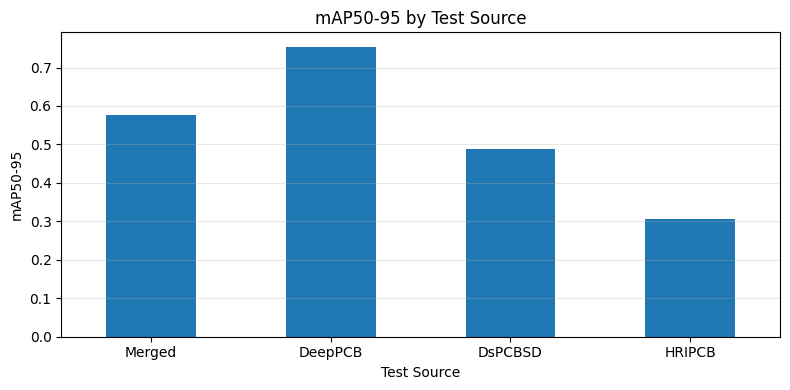

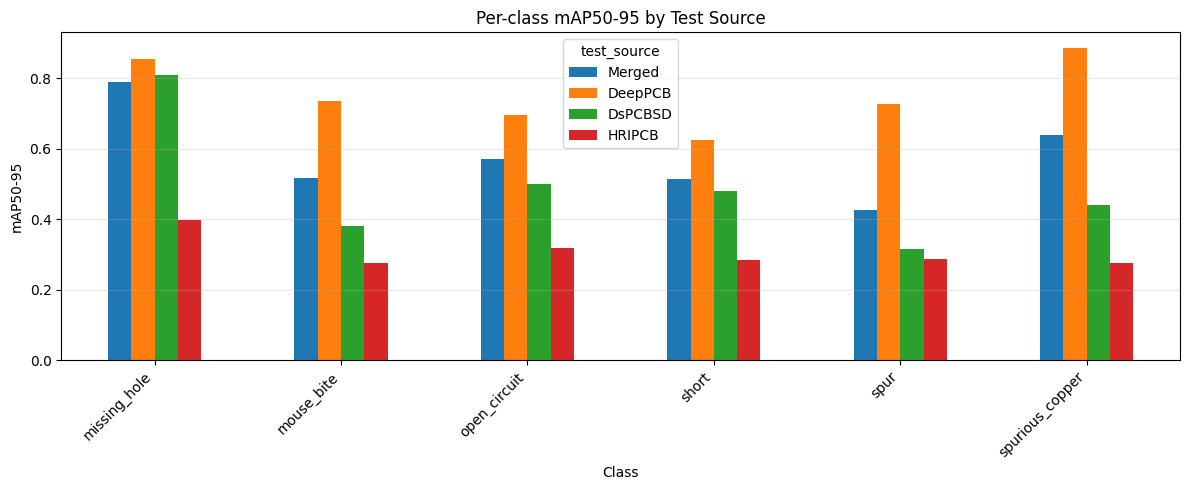

test_source,Merged,DeepPCB,DsPCBSD,HRIPCB
class_name,,,,
missing_hole,0.790293,0.854705,0.807641,0.396912
mouse_bite,0.516197,0.735941,0.381854,0.276022
open_circuit,0.571016,0.696079,0.499343,0.318397
short,0.514353,0.623553,0.479444,0.282868
spur,0.426466,0.726804,0.316750,0.285841
spurious_copper,0.638214,0.885760,0.439586,0.276049


In [10]:
plot_sourcewise_metrics(
    sourcewise_summary_df,
    REPORT_DIR / f"{TRAIN_NAME}_sourcewise_map50_95.png",
)

per_class_source_pivot = plot_per_class_sourcewise(
    sourcewise_per_class_df,
    REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_map50_95.png",
)

if per_class_source_pivot is not None:
    display(per_class_source_pivot)
    per_class_source_pivot.to_csv(REPORT_DIR / f"{TRAIN_NAME}_sourcewise_per_class_pivot.csv")

## 10. Show training artifacts

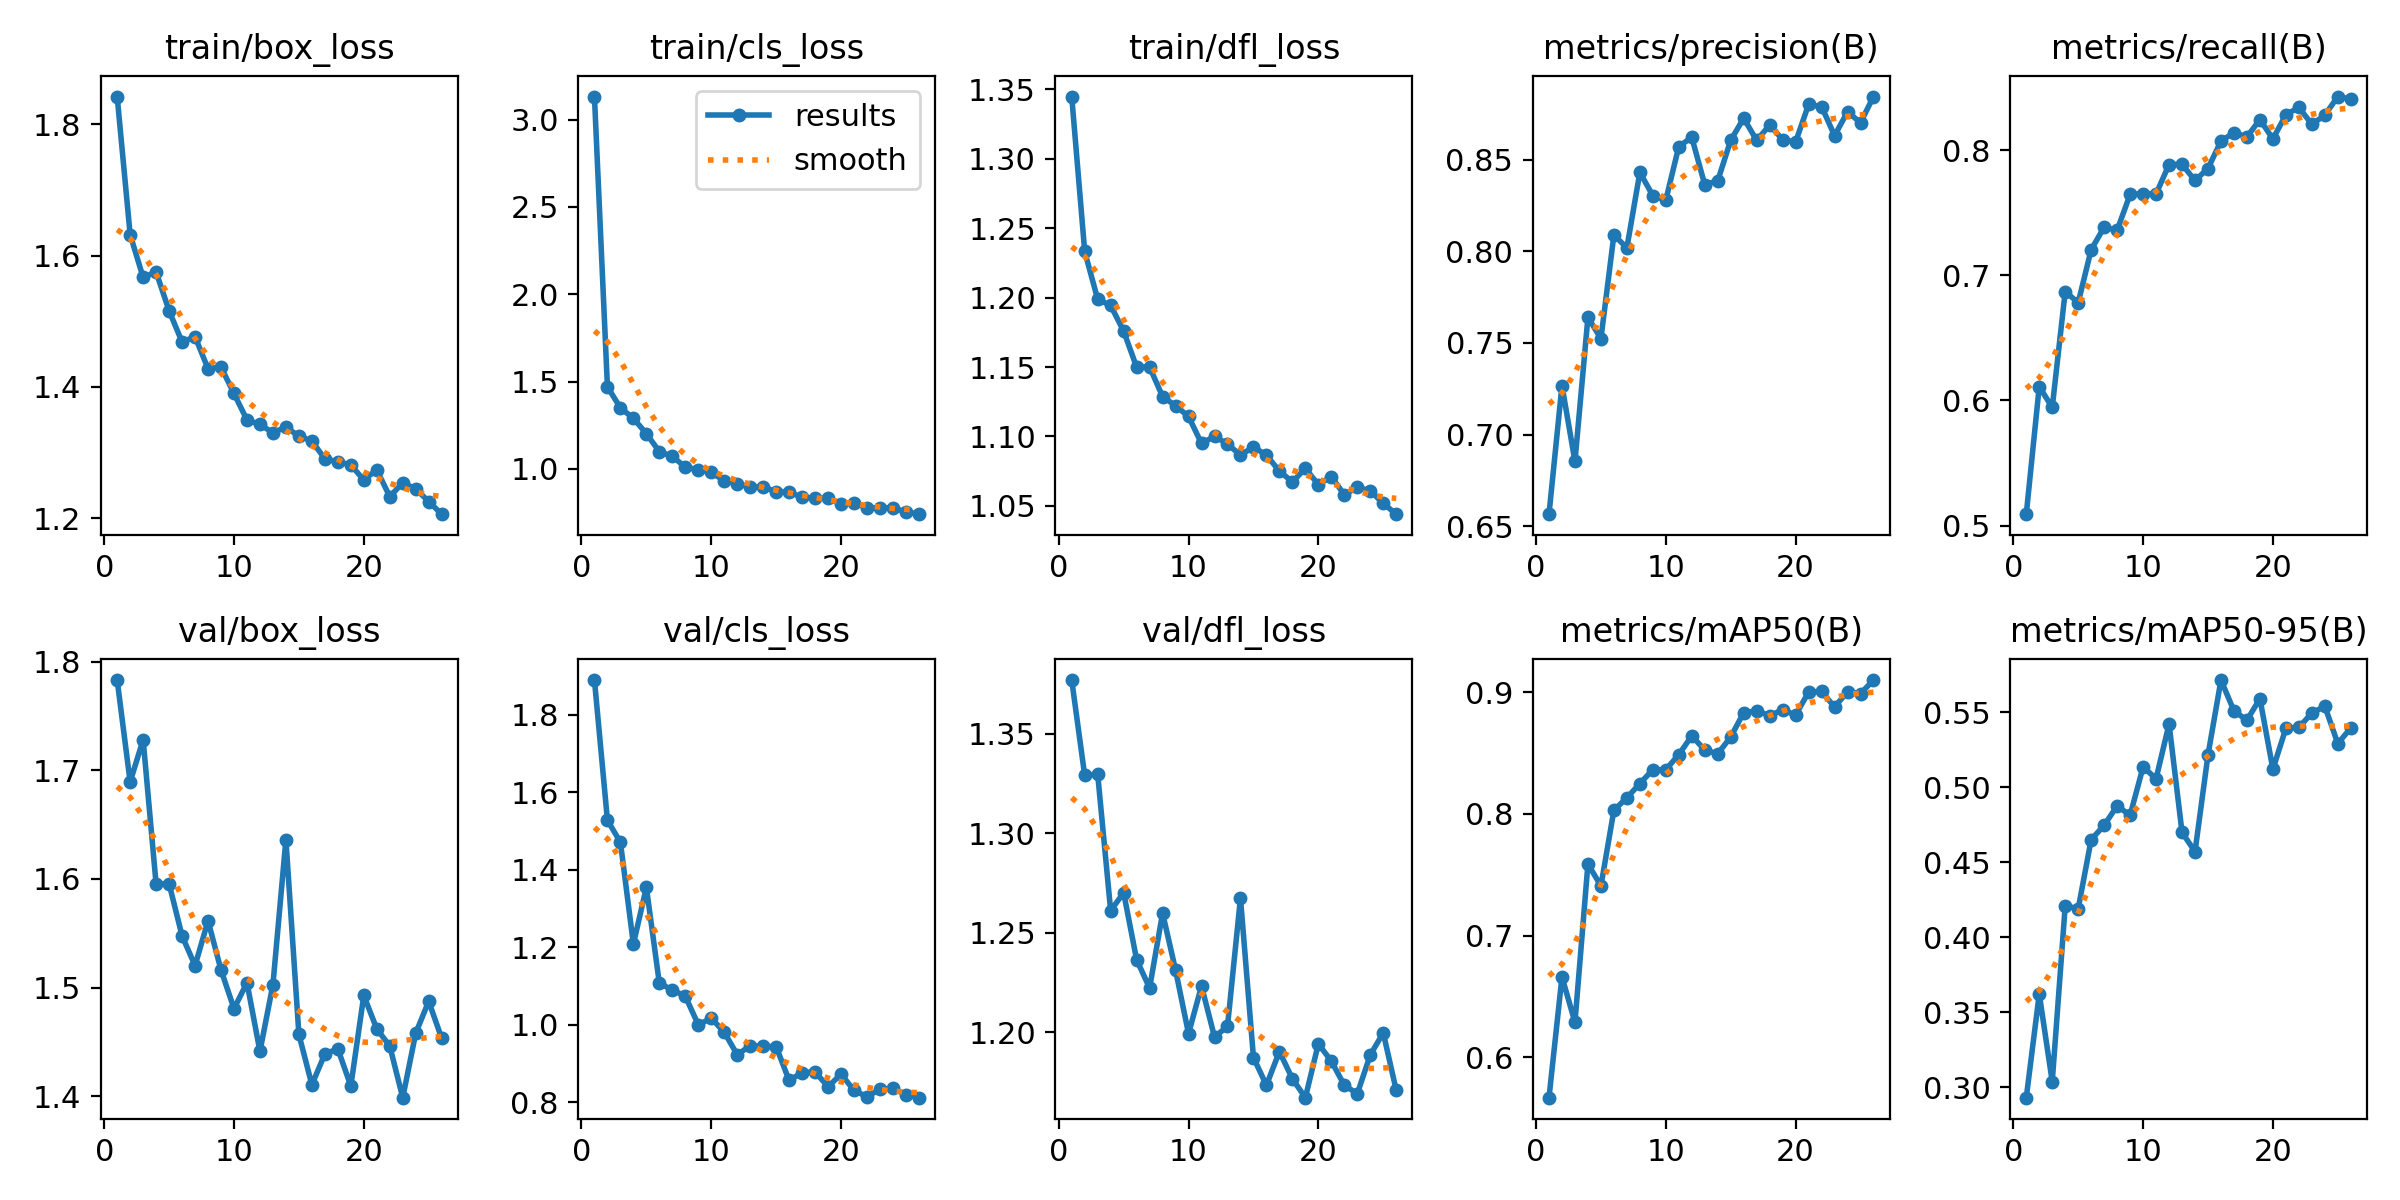

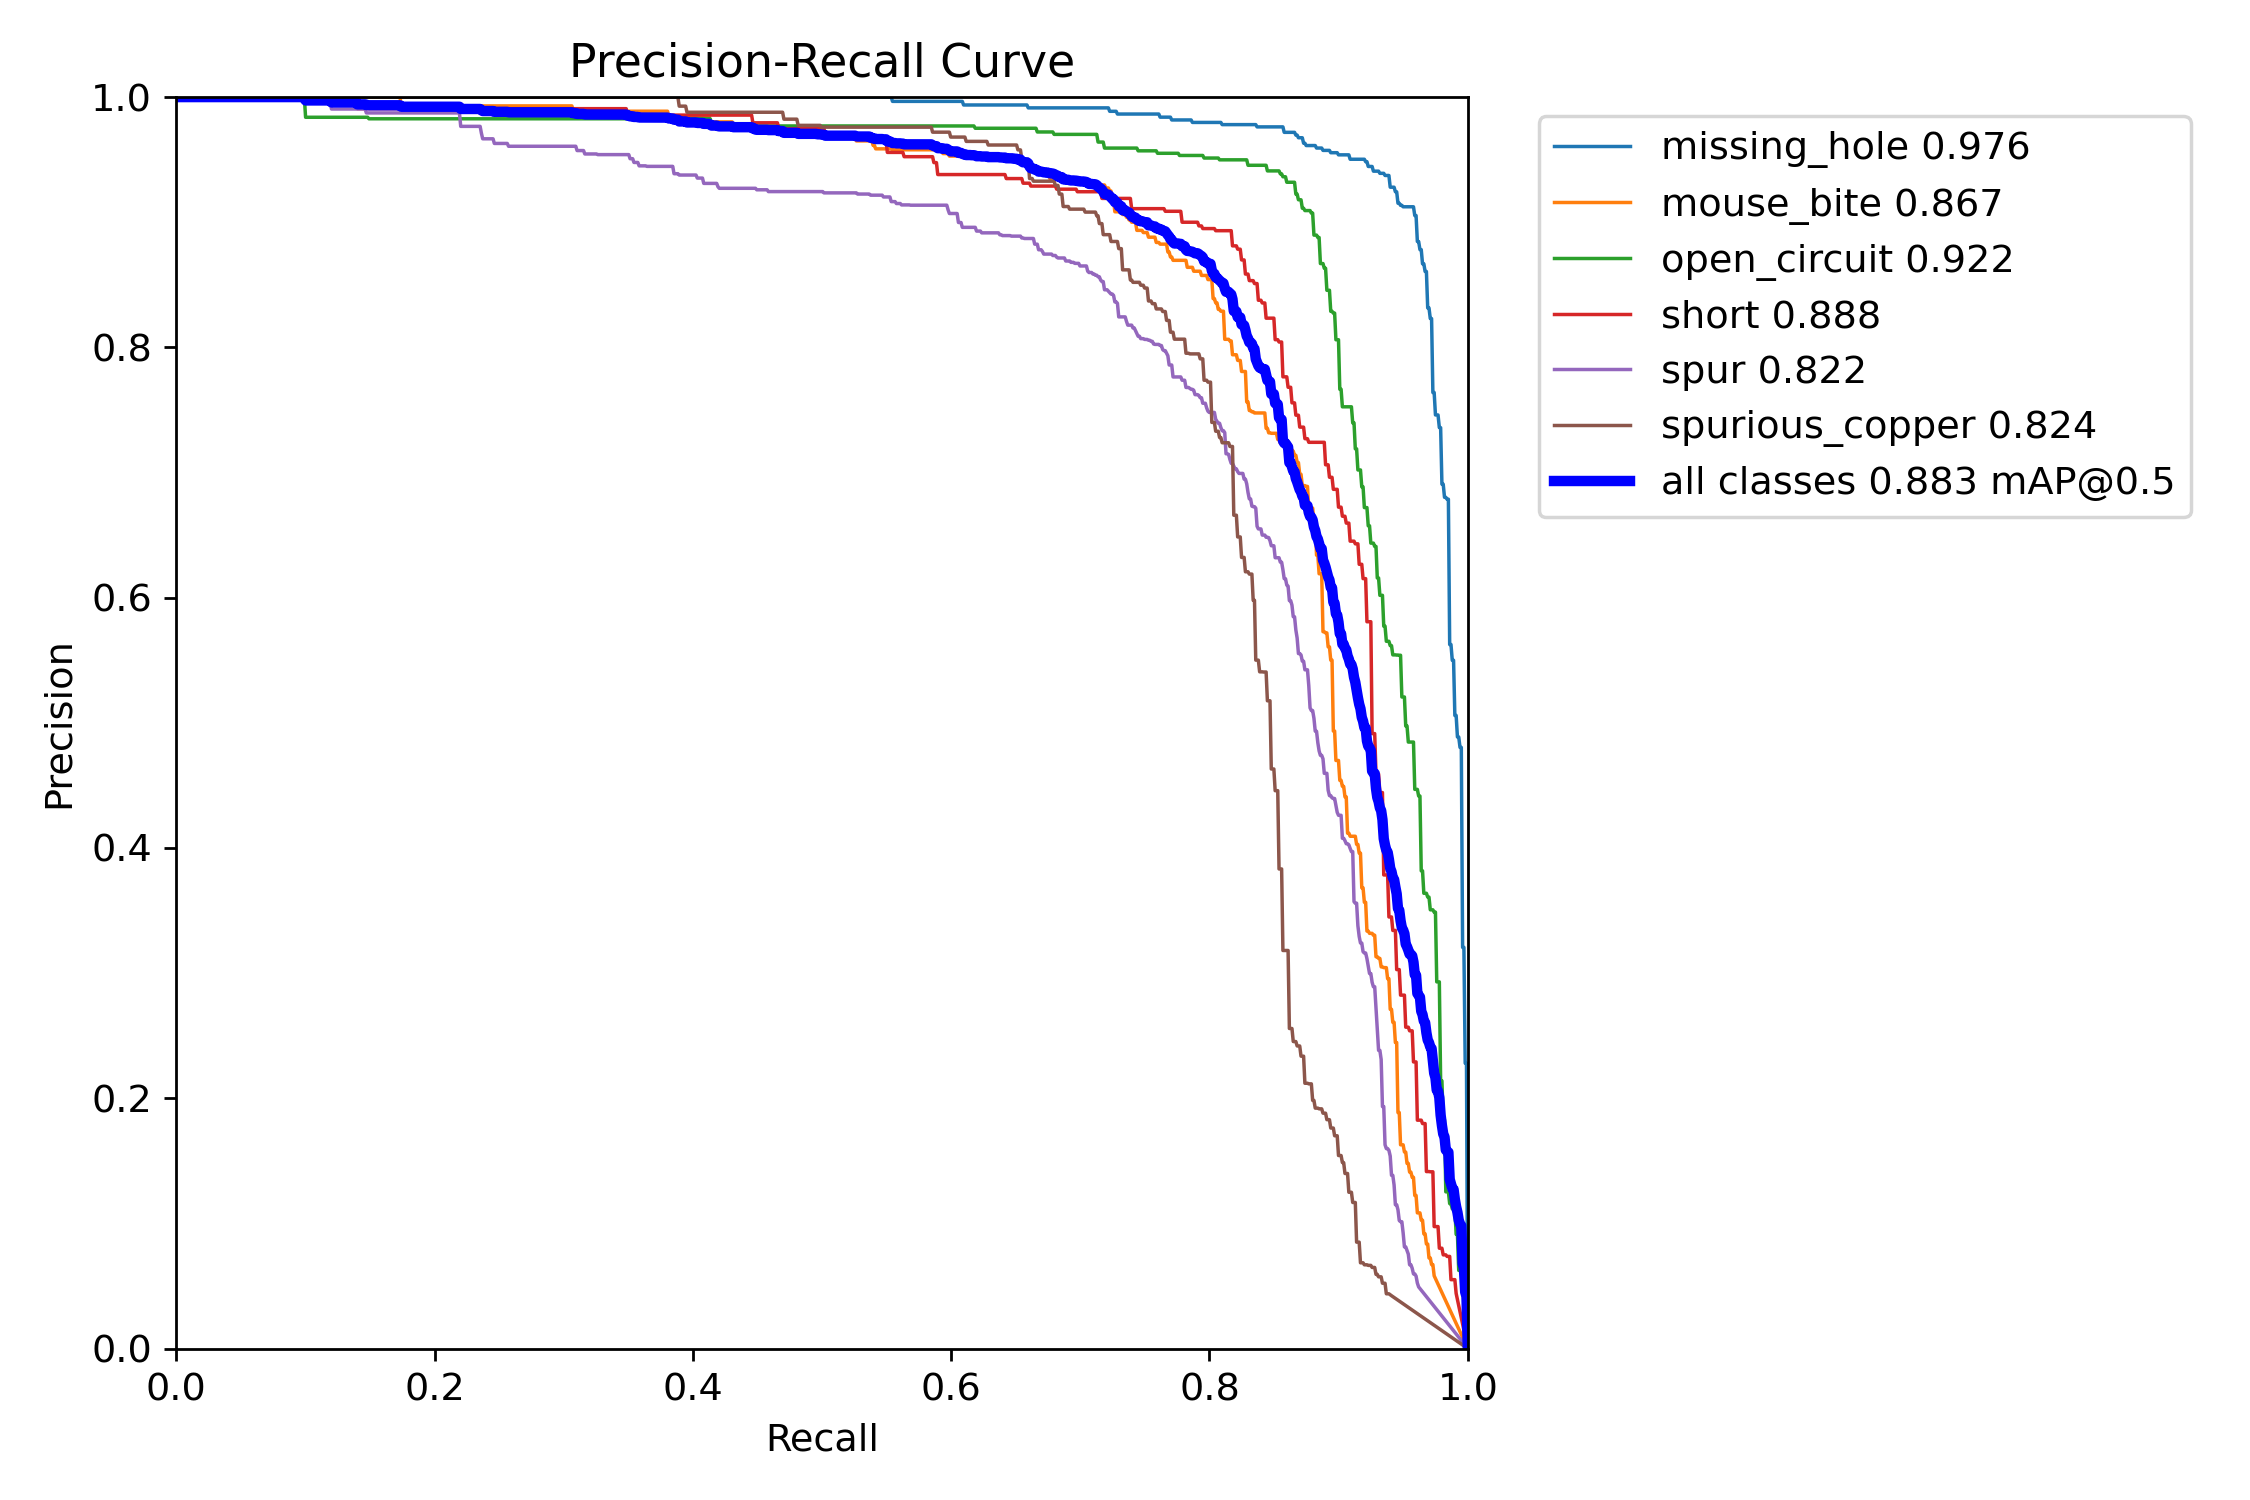

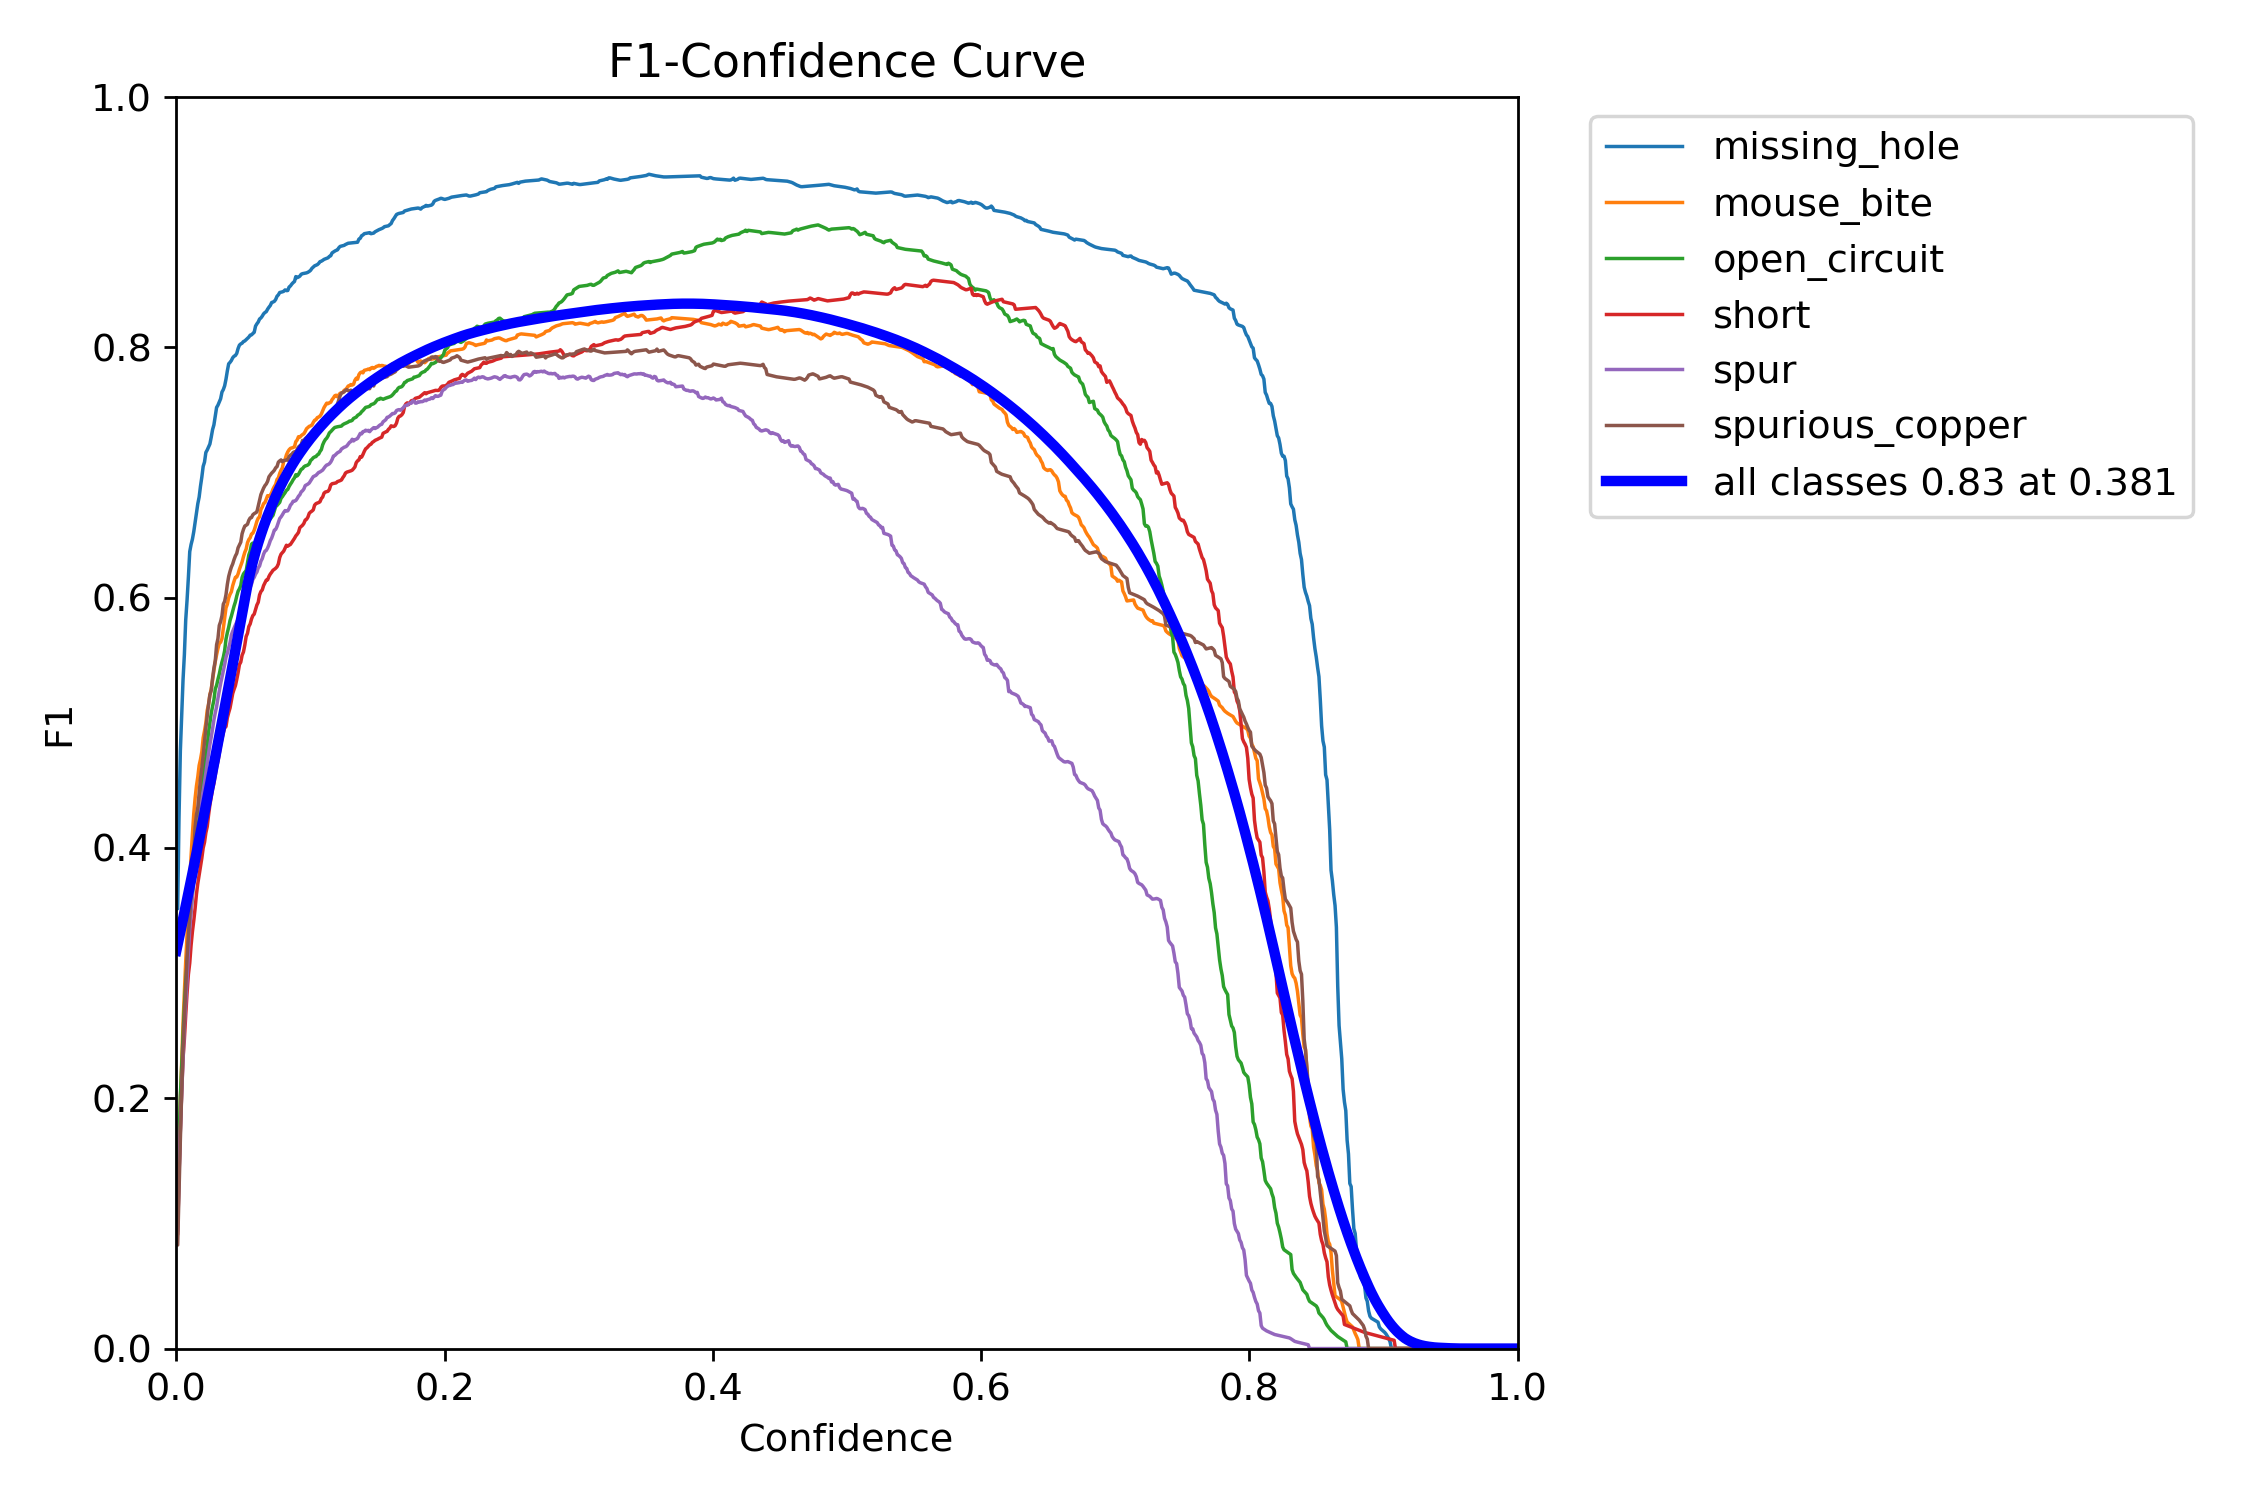

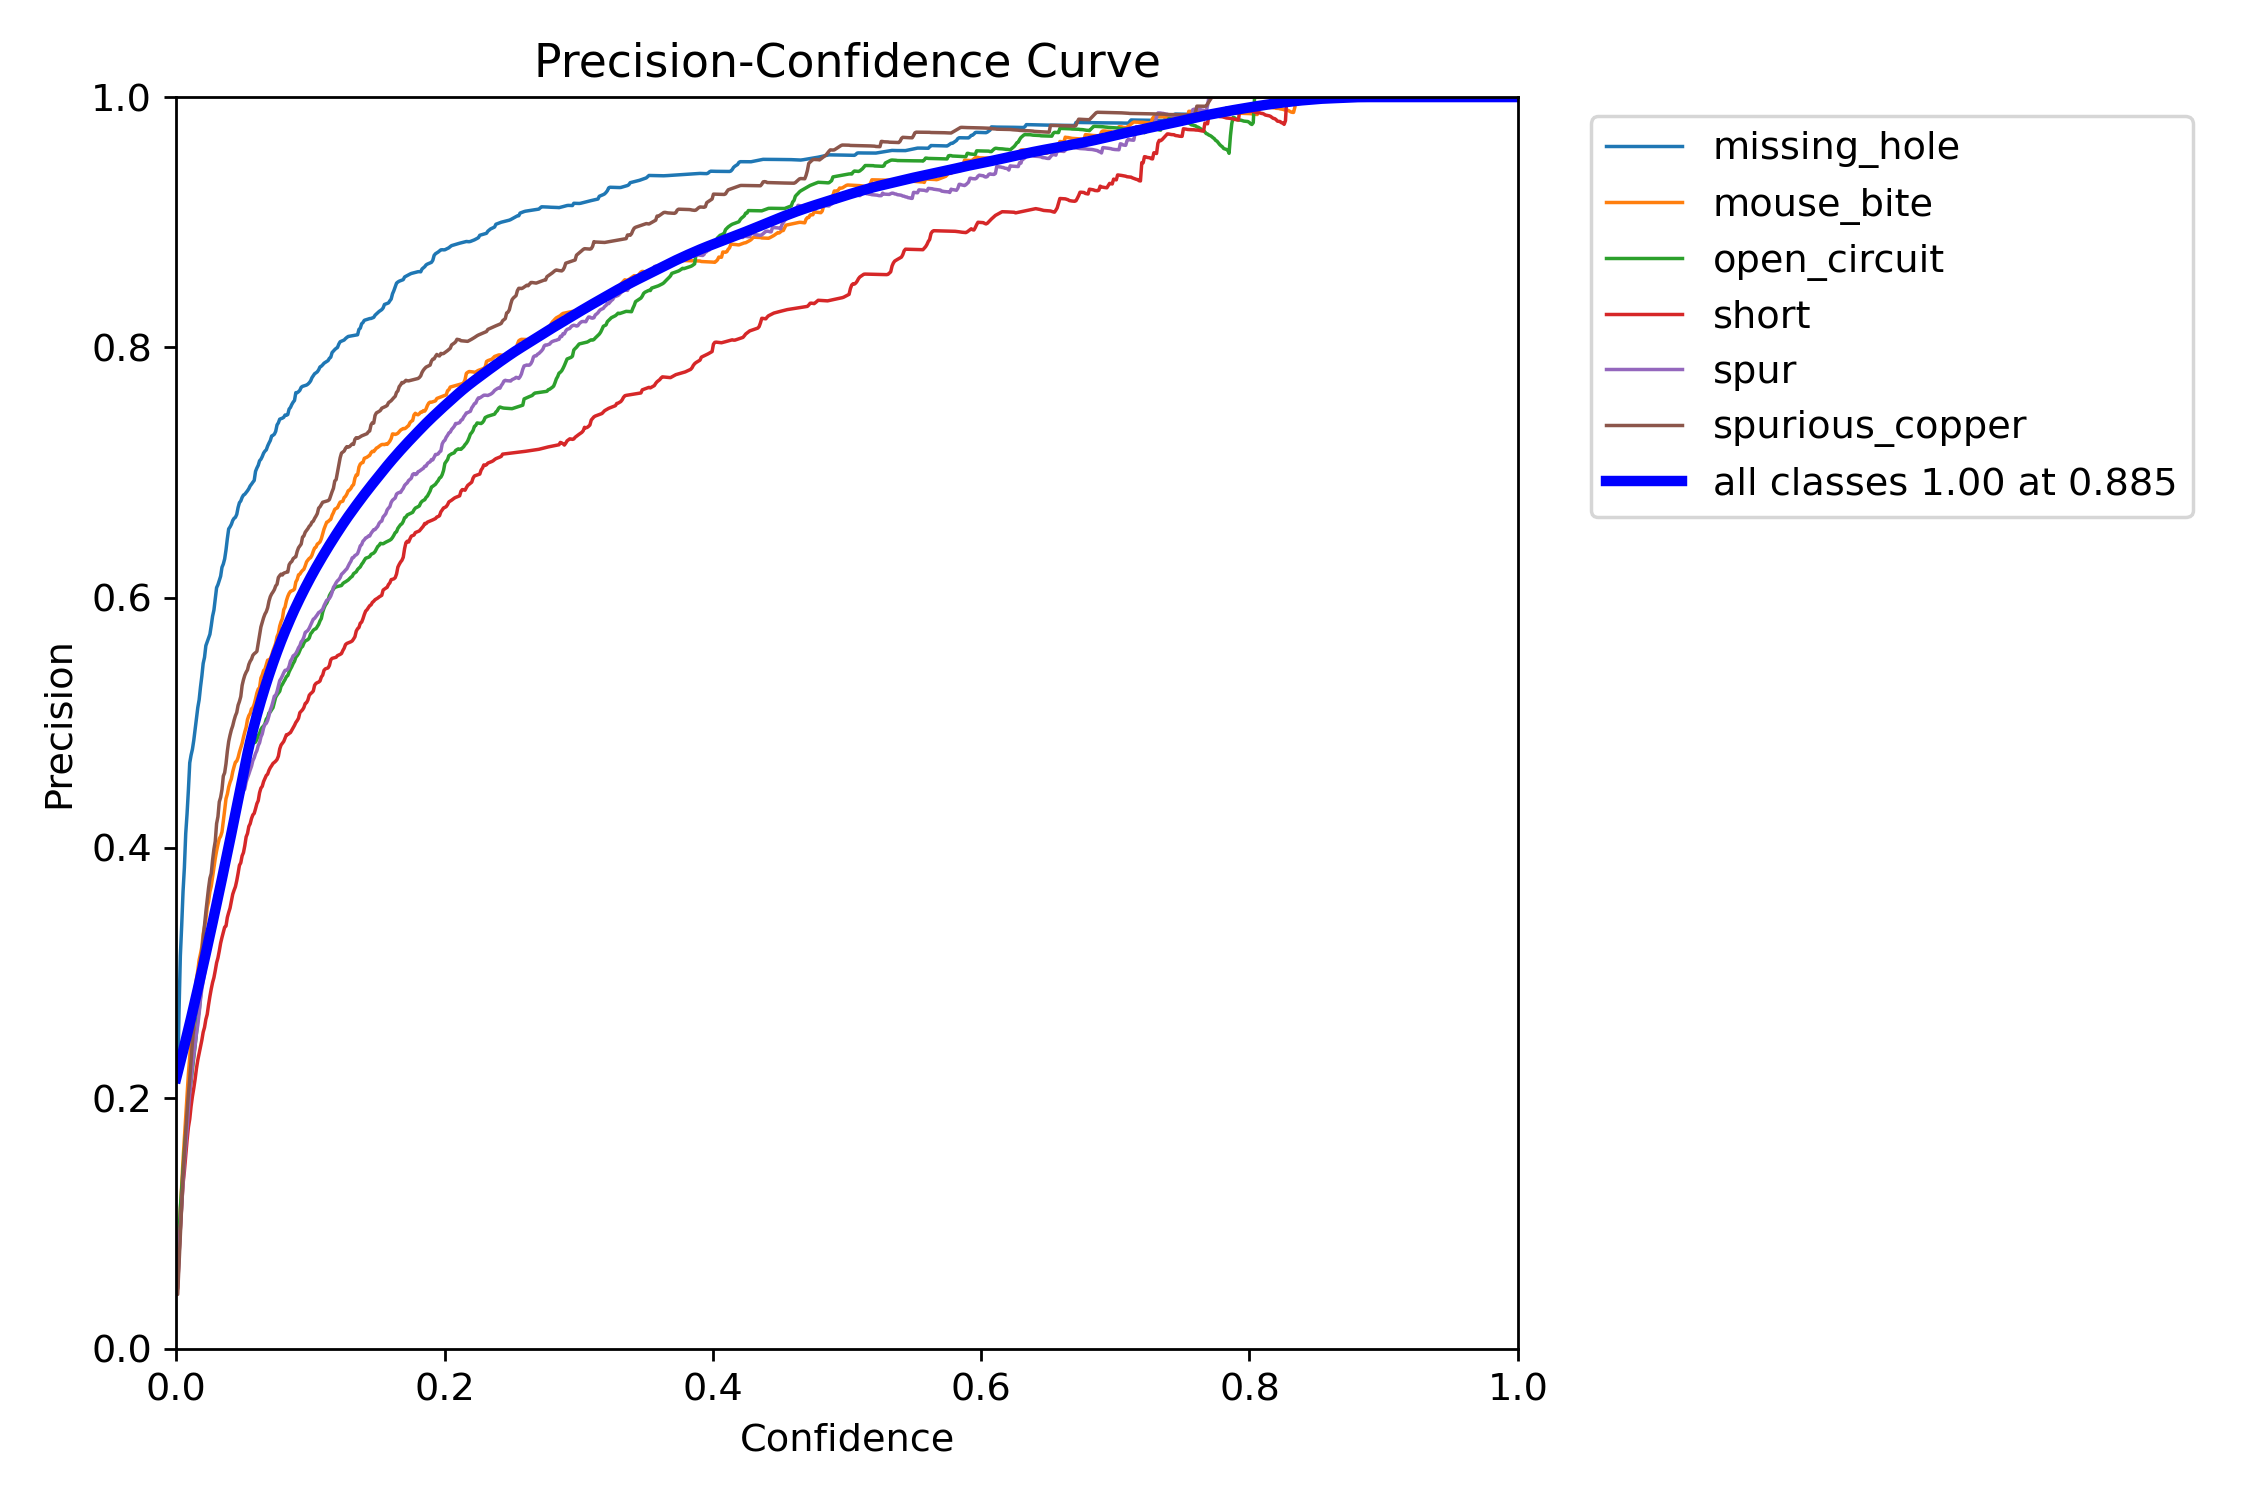

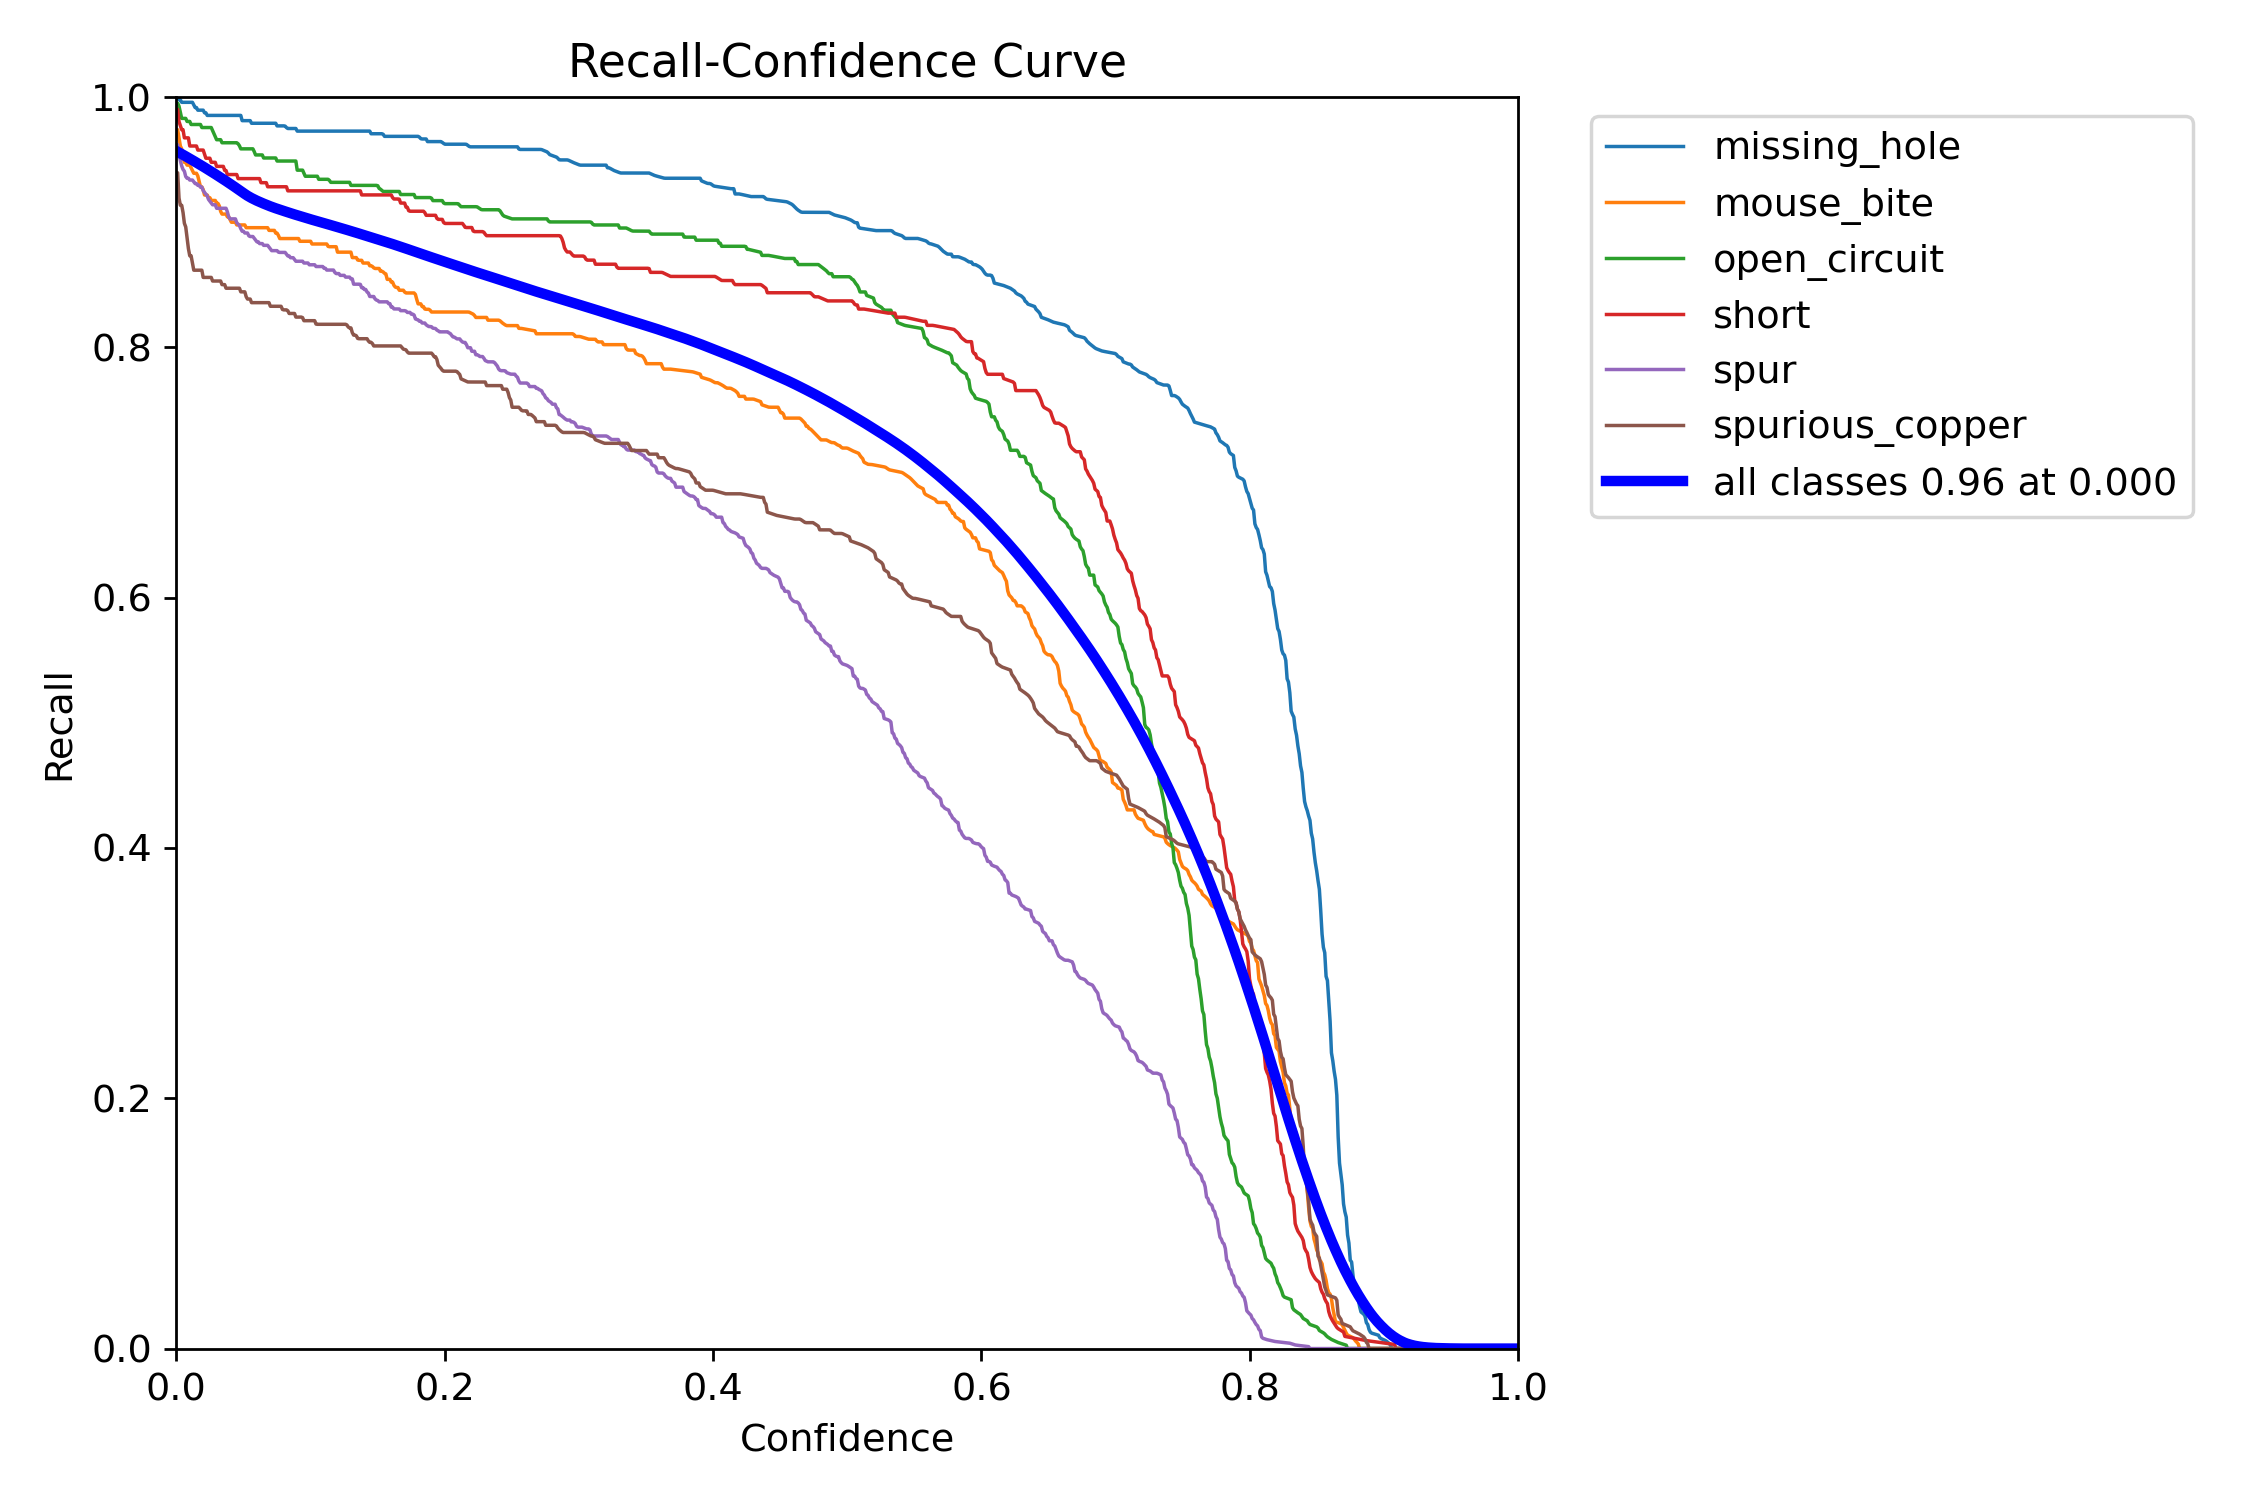

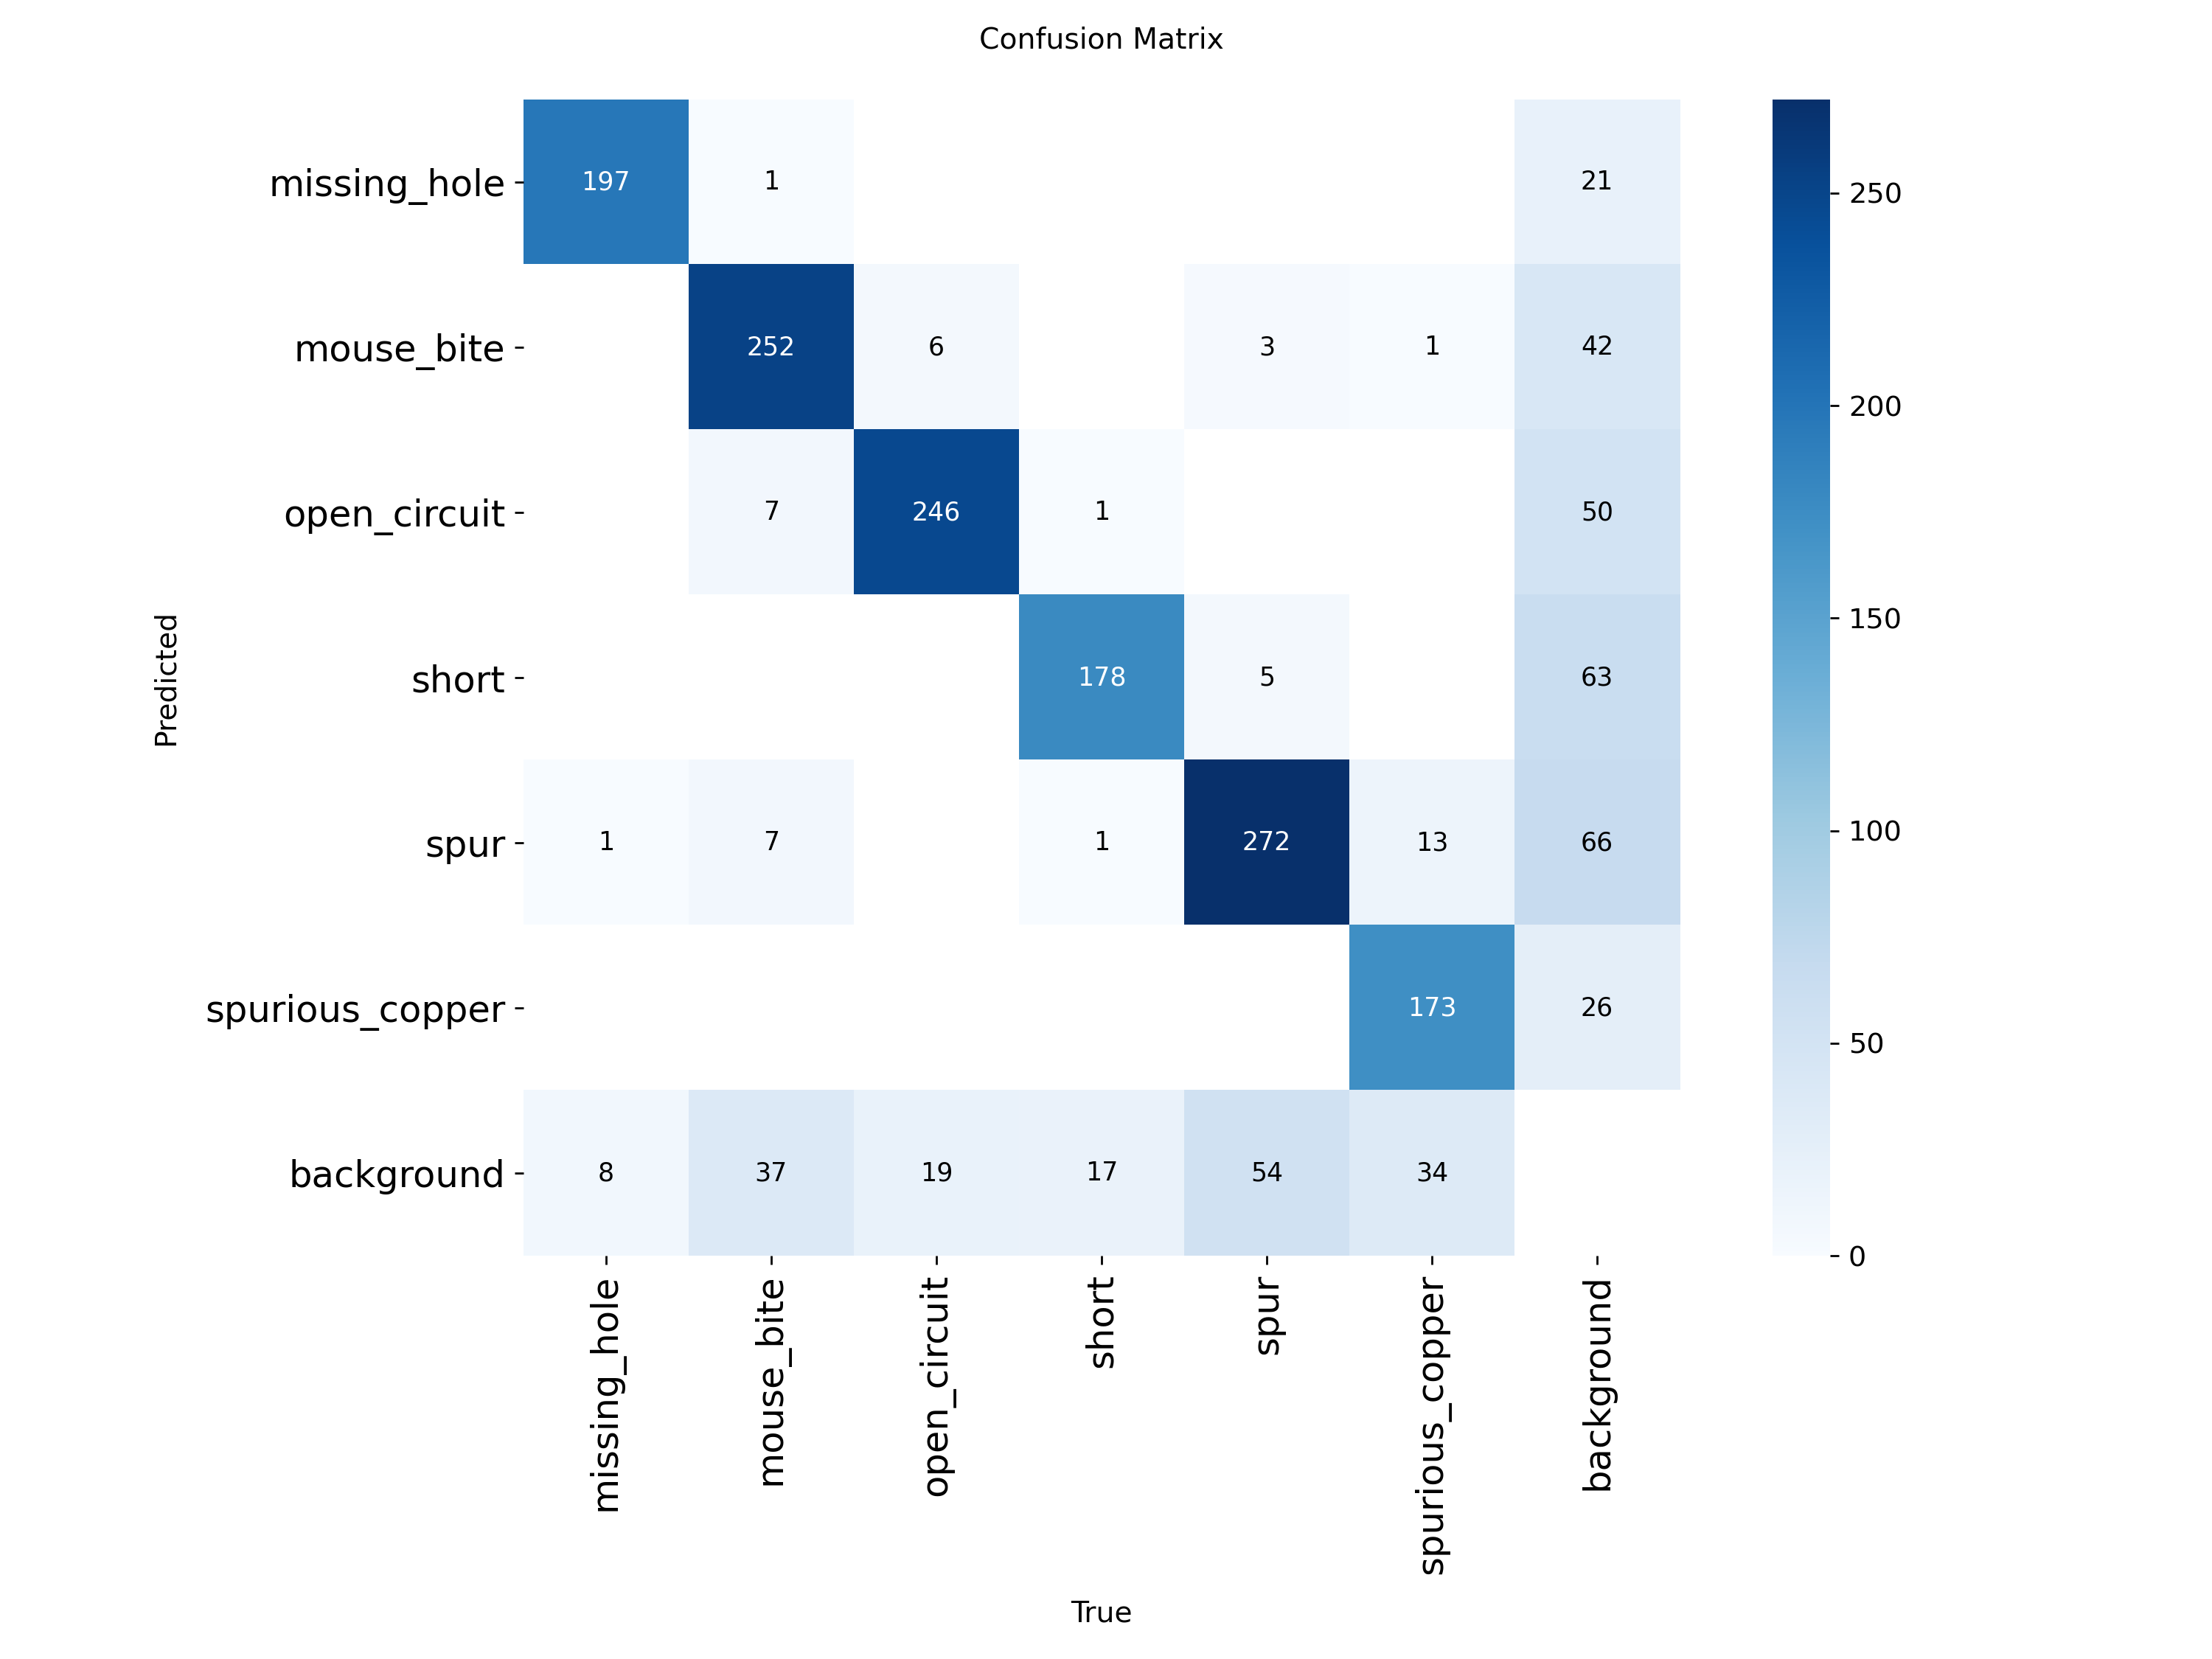

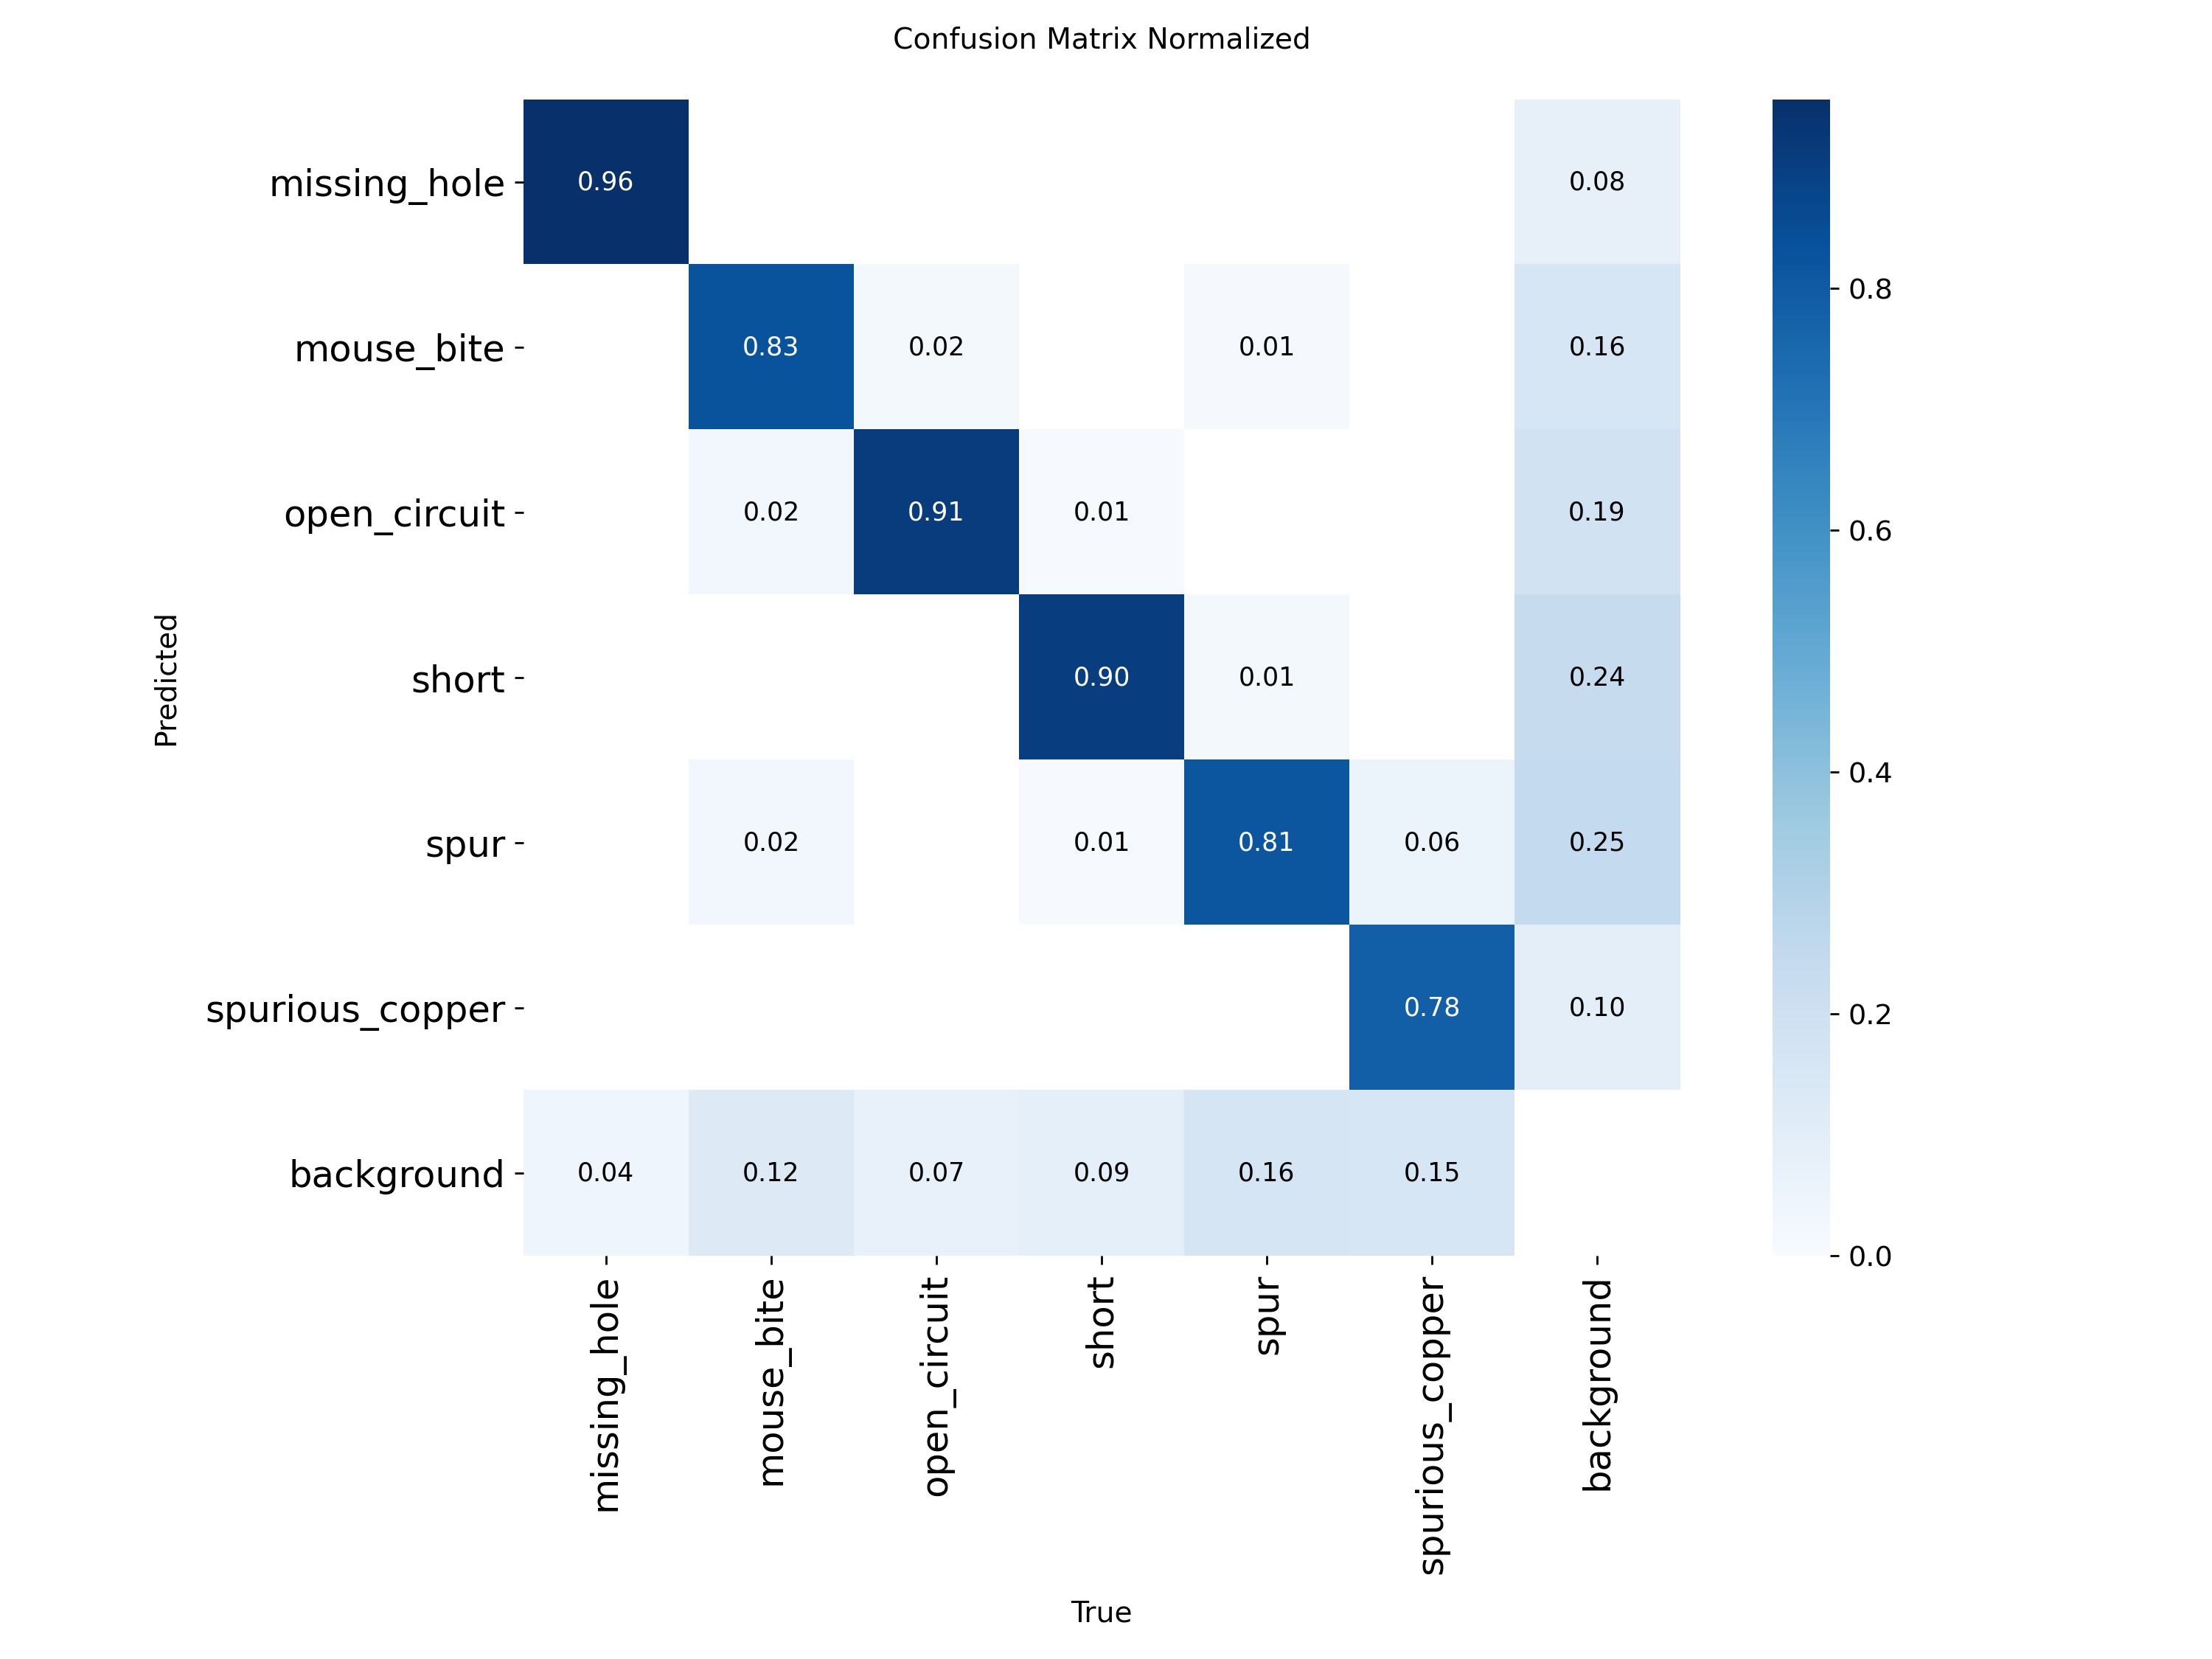

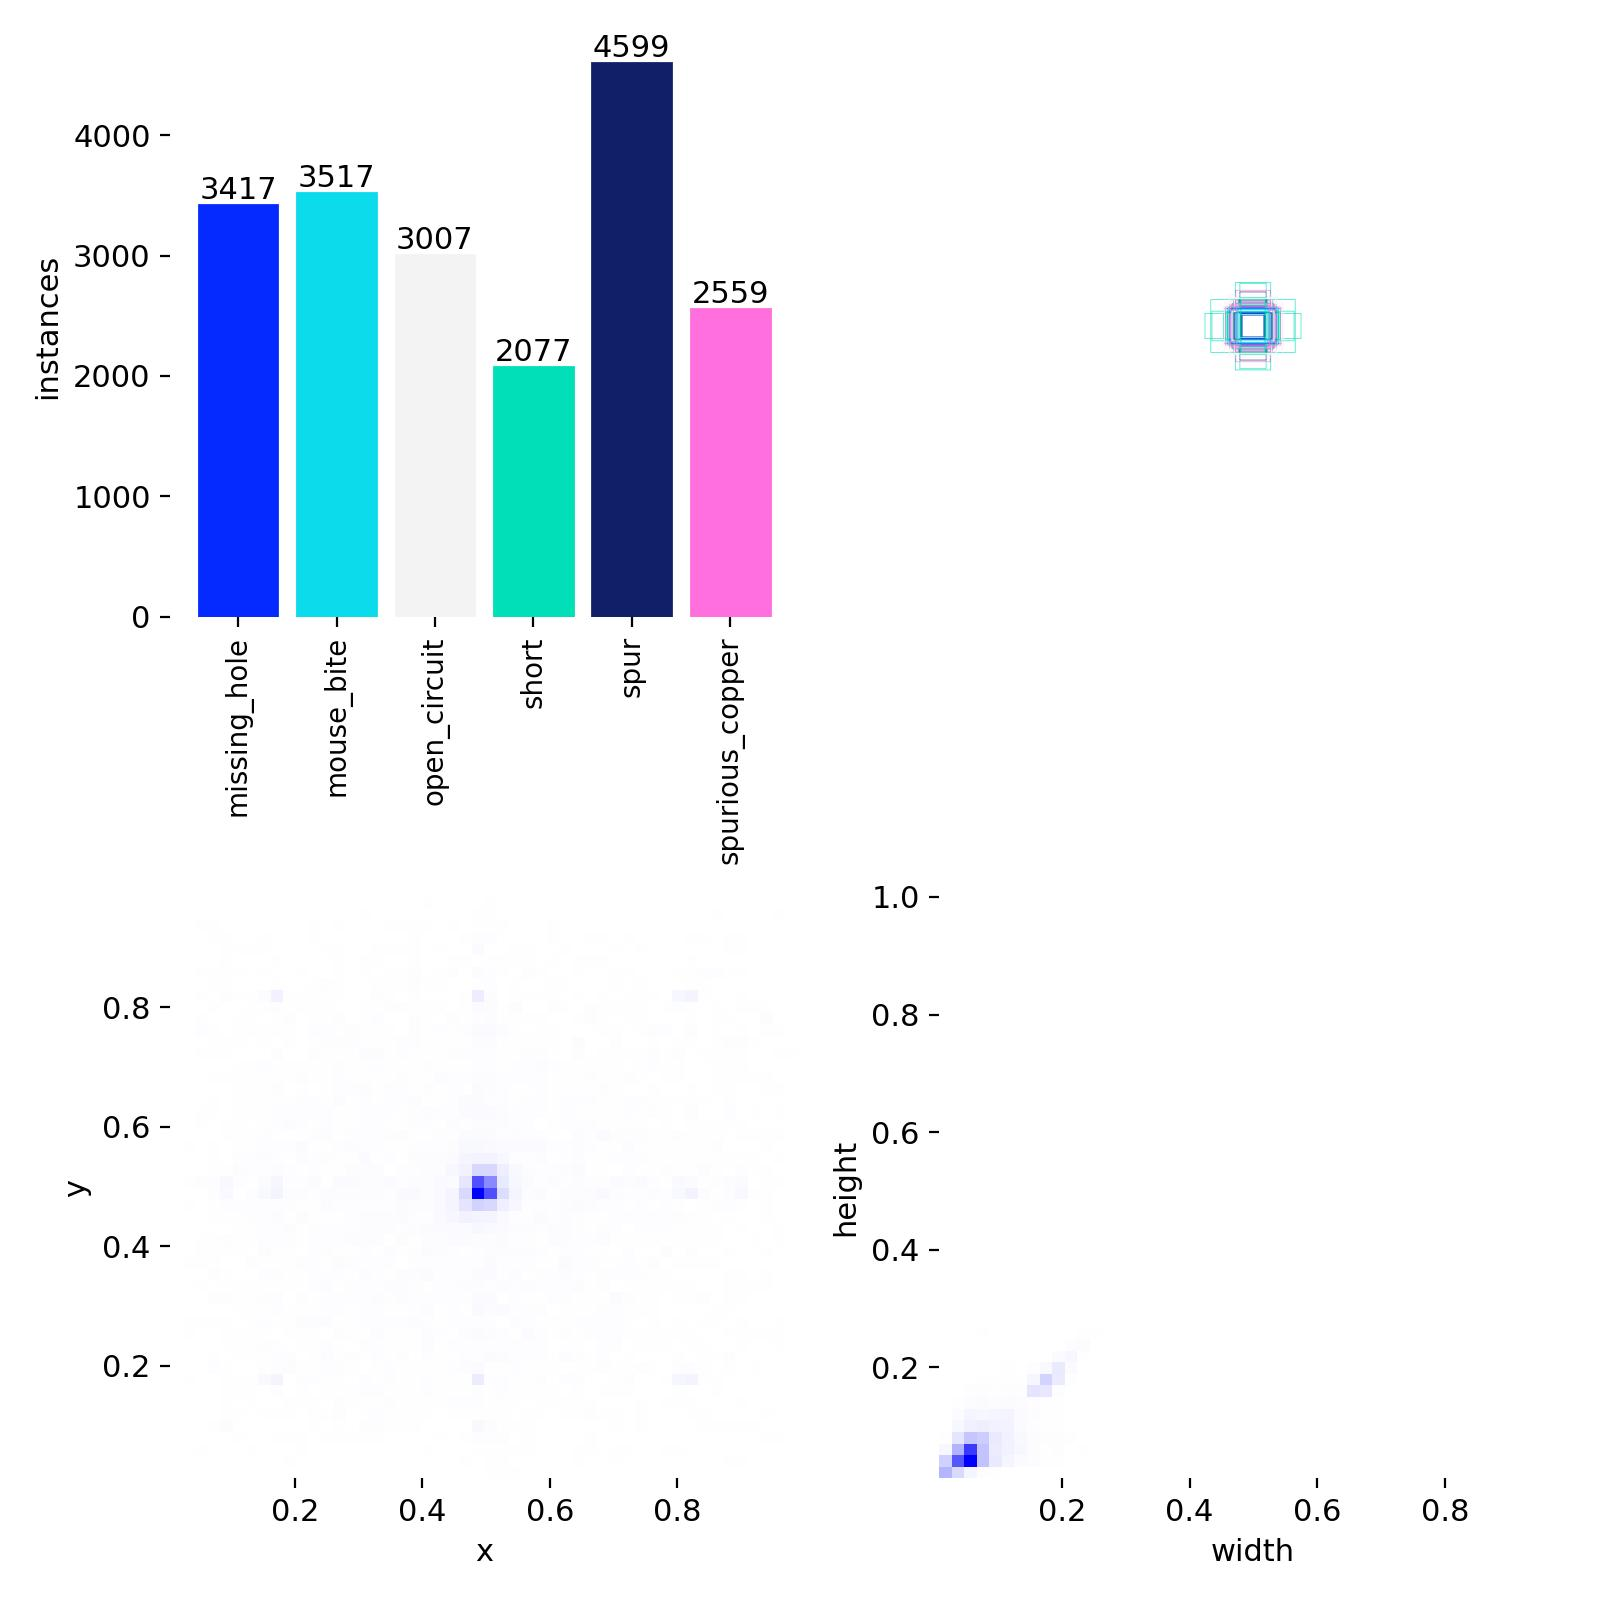

In [11]:
train_artifacts = [
    TRAIN_DIR / "results.png",
    TRAIN_DIR / "BoxPR_curve.png",
    TRAIN_DIR / "BoxF1_curve.png",
    TRAIN_DIR / "BoxP_curve.png",
    TRAIN_DIR / "BoxR_curve.png",
    TRAIN_DIR / "confusion_matrix.png",
    TRAIN_DIR / "confusion_matrix_normalized.png",
    TRAIN_DIR / "labels.jpg",
]

for p in train_artifacts:
    show_image(p)

## 11. Plot training curves

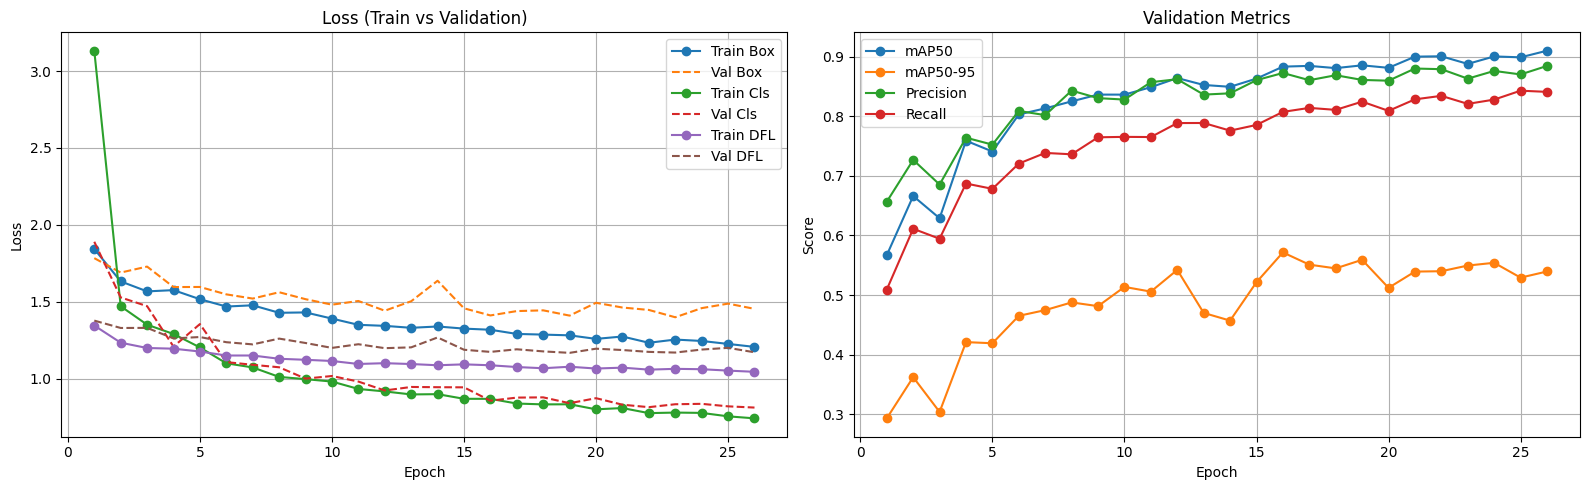

In [12]:
plot_results_csv(
    RESULTS_CSV,
    loss_cols=[
        ("train/box_loss", "Train Box", "-"),
        ("val/box_loss", "Val Box", "--"),
        ("train/cls_loss", "Train Cls", "-"),
        ("val/cls_loss", "Val Cls", "--"),
        ("train/dfl_loss", "Train DFL", "-"),
        ("val/dfl_loss", "Val DFL", "--"),
    ],
)

## 12. Predict sample test images


0: 640x640 1 mouse_bite, 10.6ms
1: 640x640 1 spur, 10.6ms
2: 640x640 1 spurious_copper, 10.6ms
3: 640x640 1 missing_hole, 10.6ms
4: 640x640 2 open_circuits, 10.6ms
5: 640x640 1 missing_hole, 3 mouse_bites, 3 open_circuits, 4 shorts, 2 spurs, 1 spurious_copper, 10.6ms
6: 640x640 3 missing_holes, 10.6ms
7: 640x640 3 missing_holes, 10.6ms
8: 640x640 2 missing_holes, 10.6ms
9: 640x640 1 spur, 10.6ms
10: 640x640 1 spurious_copper, 10.6ms
11: 640x640 1 mouse_bite, 10.6ms
12: 640x640 1 open_circuit, 2 spurious_coppers, 10.6ms
13: 640x640 1 short, 3 spurs, 10.6ms
14: 640x640 1 spur, 10.6ms
Speed: 1.6ms preprocess, 10.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/detect/PCB_Baseline/yolov11s_final_clean_6cls_test_predictions


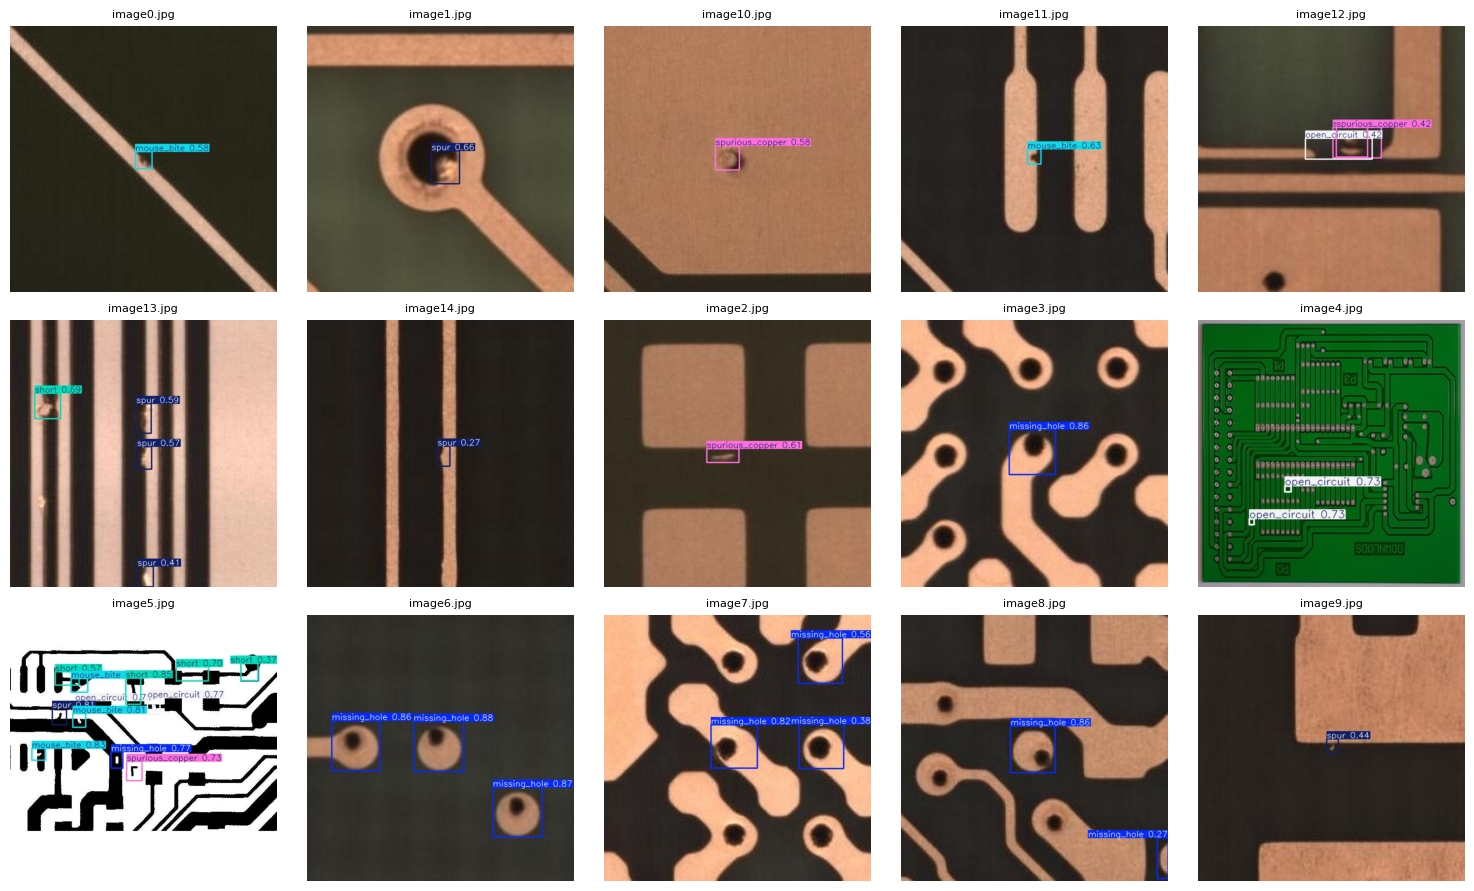

In [13]:
predict_sample_images(
    best_model=best_model,
    data_dir=DATA_DIR,
    project=PROJECT,
    pred_name=PRED_NAME,
    max_images=15,
)

display_prediction_grid(PRED_DIR, n=15)

## 13. Export artifacts

In [14]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR = ARTIFACT_DIR / TRAIN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copy train artifacts.
for file_name in [
    "results.csv",
    "results.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
]:
    src = TRAIN_DIR / file_name
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / file_name)

# Copy best/last weight.
if EVAL_PT.exists():
    shutil.copy2(EVAL_PT, EXPORT_DIR / EVAL_PT.name)

# Copy report CSV/PNG/JSON.
for p in REPORT_DIR.glob(f"{TRAIN_NAME}*"):
    shutil.copy2(p, EXPORT_DIR / p.name)

# Copy dataset/source summaries.
for p in [
    REPORT_DIR / "dataset_summary.csv",
    REPORT_DIR / "class_distribution.csv",
    REPORT_DIR / "source_test_summary.csv",
    REPORT_DIR / "source_test_class_distribution.csv",
]:
    if p.exists():
        shutil.copy2(p, EXPORT_DIR / p.name)

ZIP_OUTPUT = ROOT / f"{TRAIN_NAME}_artifacts.zip"
if ZIP_OUTPUT.exists():
    ZIP_OUTPUT.unlink()

shutil.make_archive(
    base_name=str(ZIP_OUTPUT.with_suffix("")),
    format="zip",
    root_dir=str(ARTIFACT_DIR),
    base_dir=TRAIN_NAME,
)

print("Exported:", EXPORT_DIR)
print("Created zip:", ZIP_OUTPUT)
print("Size MB:", ZIP_OUTPUT.stat().st_size / (1024 * 1024))

print("\nImportant files:")
for p in sorted(EXPORT_DIR.glob("*")):
    print("-", p.name)

Exported: /kaggle/working/yolov11s_artifacts/yolov11s_final_clean_6cls_e50
Created zip: /kaggle/working/yolov11s_final_clean_6cls_e50_artifacts.zip
Size MB: 18.33574867248535

Important files:
- BoxF1_curve.png
- BoxPR_curve.png
- BoxP_curve.png
- BoxR_curve.png
- best.pt
- class_distribution.csv
- confusion_matrix.png
- confusion_matrix_normalized.png
- dataset_summary.csv
- labels.jpg
- results.csv
- results.png
- source_test_class_distribution.csv
- source_test_summary.csv
- yolov11s_final_clean_6cls_e50_sourcewise_map50_95.png
- yolov11s_final_clean_6cls_e50_sourcewise_metrics.json
- yolov11s_final_clean_6cls_e50_sourcewise_per_class_map.csv
- yolov11s_final_clean_6cls_e50_sourcewise_per_class_map50_95.png
- yolov11s_final_clean_6cls_e50_sourcewise_per_class_pivot.csv
- yolov11s_final_clean_6cls_e50_sourcewise_summary_metrics.csv


## Files to download

Download the artifact zip:

```text
/kaggle/working/yolov11s_final_clean_6cls_e50_artifacts.zip
```

Important exported files:

- `yolov11s_final_clean_6cls_e50_sourcewise_summary_metrics.csv`
- `yolov11s_final_clean_6cls_e50_sourcewise_per_class_map.csv`
- `yolov11s_final_clean_6cls_e50_sourcewise_per_class_pivot.csv`
- `yolov11s_final_clean_6cls_e50_sourcewise_map50_95.png`
- `yolov11s_final_clean_6cls_e50_sourcewise_per_class_map50_95.png`